In [10]:
# Nettoyage complet
print("Nettoyage...")
%reset -f

%whos

Nettoyage...
Interactive namespace is empty.


In [11]:
# Import de tous les packages dont on va avoir besoin

import numpy.random as rd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import pandas as pd 
from sqlalchemy import create_engine
from sqlalchemy.engine import URL
from sqlalchemy import text
import sqlalchemy
import gc
import pyodbc
import os
from datetime import datetime
from pandas import NaT
import math
from scipy.stats import expon
import geopandas as gpd
from shapely.geometry import Point
import contextily as ctx
from geopy.geocoders import Nominatim
from geopy.exc import GeocoderTimedOut, GeocoderUnavailable
import time
from scipy.stats import gaussian_kde
from sklearn.neighbors import KernelDensity
from scipy.stats import gaussian_kde
import pickle
from joblib import Parallel, delayed
from matplotlib.colors import LogNorm
from matplotlib.colors import PowerNorm 
from shapely.geometry import Point, Polygon
from shapely.ops import unary_union, polygonize
from scipy.spatial import Voronoi
from shapely.geometry import box
from shapely.ops import unary_union
from geopy.distance import geodesic
from geovoronoi import voronoi_regions_from_coords
import requests
import geodatasets
import cartopy
import cartopy.io.shapereader as shpreader
import concurrent.futures
import psutil

Edit : dans les faits j'ai pas vraiment fait comme ça.

Précisions sur la démarche : 

Comme dans les modèles macroéconomiques microfondés, on part du plus bas niveau pour en déduire le comportement global du marché : les négociateurs, de par leurs caractéristiques observées, vont nous permettre de déduire le comportement espéré des prochains négociateurs qui pourront entrer sur le marché, anticiper les dates de sorties des autres, leur attribuer un comportement spécifique, une zone géographique définie, etc. 

Voici les étapes : 

Entrée des négociateurs et simulation des comportements. Un nouveau négociateur entre sur le marché pour une quelconque raison : explosion du nombre d'offres dans un espace donné à cause de nouvelles constructions, par exemple, ce qui mène une agence à recruter. A partir de là, il faut lui définir un profil : on le fait entrer dans une agence, qui soit existe déjà, soit le négociateur crée son agence. On lui attribue un comportement selon la distribution estimée des comportements des négociateurs que l'on connaît déjà : quantité de lots qu'il gèrera en simultané, superficie et prix des offres qu'il commercialisera, probabilité qu'il parvienne à chaque étape de la commercialisation à passer à la suivante, etc. 

Entrée de nouvelles offres et simulation de nouvelles constructions. Un nouveau bâtiment est créé. Il entre sur le marché côté offres, une agence s'en saisit, et en fonction de la taille de ce nouveau bâtiment, un ou plusieurs négociateurs se partagent le gâteau, ils se retrouvent donc avec un certain nombre de nouvelles offres et donc de nouveaux lots à pourvoir. On commencera par une projection prophet du nombre de nouvelles constructions à attendre par zone géographique dans les prochains mois. Pour la quantité d'offres et de lots qui seront à offrir dans ce nouveau bâtiment, on les simulera selon la distribution empirique de la taille des nouveaux bâtiments construits, puis, si trop de nouveaux lots sont à prendre en charge par rapport aux habitudes des négociateurs des environs, de nouvelles agences pourront voir le jour, ou de nouveaux négociateurs seront embauchés. 

Comportement des entreprises. Elles peuvent soit changer de bureaux, soit venir d'être créées. Dans le premier cas, on peut estimer la distribution de la nouvelle taille demandée à partir de la taille précédente, en utilisant une distribution empirique avec comme paramètre la taille des locaux précédemment occupés. Les locaux nouvellement disponibles reviendront alors sur le marché des offres, générant ainsi de nouveaux lots à pourvoir, et alimentant par la même occasion le stock d'offres des négociateurs. Dans le deuxième cas, l'entreprise nouvellement créée recherchera des petits locaux, et avec une certaine probabilité, un entrepôt pour aller avec. Dans tous les cas, pour choisir son nouveau fief, l'entreprise se questionnera sur le meilleur endroit, la meilleure disposition des locaux, et effectuera plusieurs visites, avec plusieurs négociateurs, le tout sous contrainte de rester en deça d'une certaine distance maximale acceptable au lieu de résidence des collaborateurs. Ce processus de décision, visites, puis déménagement ou emménagement effectif se fera sur plusieurs mois. Il sera facilité si peu de négociateurs et de locaux sont disponibles dans les environs, et donnera l'embarras (le mot est bien choisi) du choix à l'entreprise si de nombreux locaux sont disponibles dans les environs et que de nombreux négociateurs s'arrachent le contrat. Possibilité d'estimation du nombre de visites par une entreprise avant de se décider en régressant cette quantité sur la distance moyenne aux bureaux, le nombre d'offres disponibles dans ce rayon, et le nombre de négociateurs actifs dans ce rayon.

Génération des demandes. En se mettant à rechercher des locaux, les entreprises consultent les sites des agences immobilières alentours et ainsi génèrent un nombre aléatoire de demandes dépendant du nombre d'agences à proximité, du nombre d'offres disponibles dans chacune des agences qu'elles consulteront successivement, et des spécificités des besoins de l'entreprise. Ces dernières seront : bureaux, commerces, restaurants ? Surface recherchée ? Rez-de-chaussée obligatoire (à relier au type d'activité de l'entreprise) ?

Processus de négociation sous-jacent. Création d'une demande pour une agence. Un des négociateurs s'en saisit, celui qui est le plus rapproché en proportion de ses habitues de gestion en ce qui concerne le nombre de demandes à gérer. Le négociateur propose un nombre aléatoire d'offres à son client, dont la loi dépend de ses habitudes. Si l'entreprise trouve chaussure à son pied parmi ces offres, le négociateur organise une visite, qui a ensuite une certaine probabilité d'aboutir, dont ce dernier paramètre de Bernoulli dépend du caractère du négociateur. Une fois signé, le montant de la transaction est versé au négociateur (pour simplifier les choses, car en l'état on ne peut pas savoir quels groupe ont de l'argent d'avance ou non, et donc on ne peut pas estimer les quels seraient enclins à embaucher et lesquels seraient les plus motivés à adopter une stratégie agressive pour obtenir les contrats). 

Le modèle fonctionnerait en temps discret, par périodes d'une semaine, et on réajuste l'état du marché à chacune d'entre elles. Il s'agit d'une sorte de marche aléatoire d'entreprises sur l'ensemble des bureaux localement présents, dont la loi de chaque mouvement est compliquée à estimer au vu de la quantité d'acteurs qui entrent en jeu, et de caractéristiques aléatoires de ces derniers. L'état futur attendu s'estimera au plus simple, par méthode de Monte Carlo.

Quantités à estimer : Quels sont les lieux où une forte activité est à prévoir ?  Quel est le taux de vacance attendu par zone géographique ? Le modèle rend-il bien compte de l'état actuel du marché ? Est-on proche ou éloigné d'un état stationnaire ? Le marché présente-t-il des caractéristiques cycliques, ou une croissance régulière ? A quel point l'occurence de chocs est-elle probable ? De nouveaux concurrents sont-ils susceptibles d'émerger ? Où sont les opportunités ? Quels concurrents empiettent le plus sur le potentiel de croissance d'une agence ?

In [12]:
# Connexion pyodbc à SQL Server

conn_str = (
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=172.16.11.34;"
    "DATABASE=LogiProDev;"
    "UID=quentin;"
    "PWD={Barbidur1;SQL}"
)

conn = pyodbc.connect(conn_str)
cursor = conn.cursor()

# Les requêtes : 

requete_lots_infos_basiques = """
SELECT 
    tj.lot_id,
    l.lot_actif,
    l.lot_date_creation,
    l.lot_date_archive,
    l.lot_surface,
    l.lot_batiment,
    l.etage_id,
    l.adresse_id,
    o.negociateur_id
FROM dbo.tj_offre_lot tj
JOIN dbo.t_lot l ON tj.lot_id = l.lot_id
JOIN dbo.t_offre o ON o.offre_id = tj.offre_id
WHERE l.lot_actif = 1
"""

requete_lots_loyer = """
SELECT 
    tj.lot_id,
    tj.ol_actif,
    tj.offre_id,
    tj.ol_loyer
FROM dbo.tj_offre_lot tj
WHERE tj.ol_actif = 1
"""

requete_lots_adresses = """
SELECT 
    tj.lot_id,
    l.lot_actif,
    a.adresse_id,
    a.adr_adresse,
    a.adr_adresse_cp,
    a.adr_adresse_ville,
    CAST(a.adr_plan_x AS FLOAT) AS adr_plan_x,
    CAST(a.adr_plan_y AS FLOAT) AS adr_plan_y,
    CAST(a.adr_geo_location AS VARCHAR(255)) AS adr_geo_location,
    a.code_insee_id
FROM dbo.tj_offre_lot tj
JOIN dbo.t_lot l ON tj.lot_id = l.lot_id
JOIN dbo.t_adresse a ON l.adresse_id = a.adresse_id
WHERE l.lot_actif = 1
"""

requete_lots_codes_insee = """
SELECT 
    tj.lot_id,
    ci.code_insee_id,
    ci.ci_code_postal,
    ci.ci_code_insee,
    ci.ci_ville
FROM dbo.tj_offre_lot tj
JOIN dbo.t_lot l ON tj.lot_id = l.lot_id
JOIN dbo.t_adresse a ON l.adresse_id = a.adresse_id
JOIN dbo.tr_code_insee ci ON a.code_insee_id = ci.code_insee_id
WHERE ci.pays_id = 28
"""

requete_demandes = """
SELECT
    demande_id,
    dem_actif,
    dem_surface_minimum,
    dem_surface_maximum,
    dem_budget_minimum,
    dem_budget_maximum,
    dem_recherche_cp,
    dem_date_creation,
    dem_date_archive
FROM dbo.t_demande
WHERE dem_actif = 1
"""

requete_duree_de_vie_negos = """
-- Requête qui permettra de trouver la distribution de la durée de vie empirique des négociateurs
-- ainsi que le processus suivi par leur date d'arrivée sur le marché.
-- Le groupe dans lequel ils arrivent, on s'en fiche comme la simulation doit se faire à l'échelle globale
-- A la limite, peut-être le faire entrer en jeu plus tard pcq le groupe d'appartenance peut avoir
-- une influence sur la durée de vie du négociateur

SELECT
    negociateur_id,
    neg_nom,
    neg_prenom,
    neg_date_creation,
    neg_date_archive,
    neg_actif
FROM dbo.t_negociateur
WHERE neg_actif = 1
"""

requete_gestion_de_lots_negociateurs = """
-- Requête comptage du nombre de lots qui ont été un jour en contact avec chaque négociateur
-- Pour trouver la distribution de l'"efficacité" des négociateurs

SELECT
    n.negociateur_id,
    n.neg_nom,
    n.neg_prenom,
    n.neg_actif,
    COUNT(DISTINCT tj.lot_id) AS nombre_lots_associes
FROM dbo.t_negociateur n
LEFT JOIN dbo.t_offre o
    ON o.negociateur_id = n.negociateur_id
LEFT JOIN dbo.tj_offre_lot tj
    ON tj.offre_id = o.offre_id
    WHERE n.neg_actif = 1
GROUP BY
    n.negociateur_id,
    n.neg_nom,
    n.neg_prenom,
    n.neg_actif
HAVING COUNT(DISTINCT tj.lot_id) != 0
"""

requete_transactions_revenus_negociateurs =""" 
-- Maintenant, requête qui va chercher le nombre de transactions qu'ont fait chaque négociateur, 
-- et les revenus que ça a rapporté. Le but est de trouver leur spécialisation sur la base des recettes 
-- par transaction, mais aussi de comparer la quantité de lots avec lesquels ils ont été en contact
-- avec la quantité de transactions dans lesquelles ils vont être impliqués par la suite

SELECT
    n.negociateur_id,
    n.neg_nom,
    n.neg_prenom,
    n.neg_actif,
    n.groupe_id,
    n.agence_id,
    COUNT(t.transaction_id) AS nombre_transactions,
    SUM(t.tra_loyer) AS montant_total_transactions
FROM dbo.t_negociateur n
LEFT JOIN dbo.t_transaction t
    ON t.negociateur_id = n.negociateur_id
WHERE n.neg_actif = 1 AND t.offre_id IS NOT NULL
GROUP BY
    n.negociateur_id,
    n.neg_nom,
    n.neg_prenom,
    n.neg_actif,
    n.groupe_id,
    n.agence_id
HAVING COUNT(t.transaction_id) > 0
"""

requete_negociateurs_mandats = """ 
-- On relie maintenant les négociateurs à leurs mandats

SELECT
    n.negociateur_id,
    n.neg_nom,
    n.neg_prenom,
    m.mandat_id,
    m.mandat_type_id,
    m.man_date_creation,
    m.man_date_debut,
    m.man_date_fin,
    m.man_date_archive,
    m.man_actif
FROM dbo.t_negociateur n
LEFT JOIN dbo.t_mandat m
    ON m.negociateur_id = n.negociateur_id
WHERE m.man_actif = 1
"""

requete_agences_negociateurs = """ 
-- On relie les négociateurs à leurs agences respectives
-- Ce sera utile pour localiser les négociateurs et leur attribuer les lots qu'ils gèreront

SELECT
    n.negociateur_id,
    n.neg_nom,
    n.neg_prenom,
    n.neg_actif,
    a.agence_id,
    a.age_nom AS agence_nom,
    a.age_ville AS agence_ville,
    a.age_code_postal AS agence_code_postal,
    a.age_adresse as agence_adresse,
    a.age_actif
FROM t_negociateur n
LEFT JOIN dbo.t_agence a
    ON n.agence_id = a.agence_id
WHERE a.age_actif = 1
"""

requete_offres_dates_creation = """ 
SELECT 
    off_date_creation
FROM 
    t_offre
WHERE
    off_date_creation >= DATEADD(YEAR, -4, GETDATE())
"""

requete_dates_transac = """ 
SELECT 
    tra_date_signature
FROM 
    t_transaction
WHERE
    tra_date_signature >= DATEADD(YEAR, -4, GETDATE()) AND offre_id IS NOT NULL
"""

requete_agence_transaction = """ 
SELECT 
    agence_id 
FROM
    t_transaction
WHERE
    offre_id IS NOT NULL
"""

requete_nb_lots_negos = """ 
SELECT 
    o.negociateur_id,
    COUNT(*) AS negociateur_nb_lots_geres
FROM dbo.tj_offre_lot tj
JOIN dbo.t_offre o 
    ON tj.offre_id = o.offre_id
WHERE tj.ol_actif = 1   -- on ne compte que les lots actifs
GROUP BY o.negociateur_id
ORDER BY negociateur_nb_lots_geres DESC;
"""

requete_nb_lots_offre = """ 
SELECT 
    offre_id,
    COUNT(*) AS nb_occurrences
FROM 
    tj_offre_lot
GROUP BY 
    offre_id
"""

# Ici on a remonté toutes les données actives dans LogiPro

lots_infos_basiques = pd.read_sql_query(requete_lots_infos_basiques, conn)
print(lots_infos_basiques.columns)

lots_loyers = pd.read_sql_query(requete_lots_loyer, conn)
print(lots_loyers.columns)

lots_codes_insee = pd.read_sql_query(requete_lots_codes_insee, conn)
print(lots_codes_insee.columns)

lots_adresses = pd.read_sql_query(requete_lots_adresses, conn)
print(lots_adresses.columns)

demandes = pd.read_sql_query(requete_demandes, conn)
print(demandes.columns)

duree_de_vie_negos = pd.read_sql_query(requete_duree_de_vie_negos, conn)
print(duree_de_vie_negos.columns)

gestion_de_lots_negociateurs = pd.read_sql_query(requete_gestion_de_lots_negociateurs, conn)
print(gestion_de_lots_negociateurs.columns)

transactions_revenus_negociateurs = pd.read_sql_query(requete_transactions_revenus_negociateurs, conn)
print(transactions_revenus_negociateurs.columns)

negociateurs_mandats = pd.read_sql_query(requete_negociateurs_mandats, conn)
print(negociateurs_mandats.columns)

agences_negociateurs = pd.read_sql_query(requete_agences_negociateurs, conn)
print(agences_negociateurs.columns)

offres_dates_creation = pd.read_sql_query(requete_offres_dates_creation, conn)
print(offres_dates_creation.columns)

dates_transac = pd.read_sql_query(requete_dates_transac, conn)
print(dates_transac.columns)

agence_transaction = pd.read_sql_query(requete_agence_transaction, conn)
print(agence_transaction.columns)

nb_lots_negos = pd.read_sql_query(requete_nb_lots_negos, conn)
print(nb_lots_negos.columns)

nb_lots_offre = pd.read_sql_query(requete_nb_lots_offre, conn)
print(nb_lots_offre.columns)

conn.commit()
cursor.close()
conn.close()

C:\Users\quent\AppData\Local\Temp\ipykernel_10548\3470222273.py:253: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  lots_infos_basiques = pd.read_sql_query(requete_lots_infos_basiques, conn)


Index(['lot_id', 'lot_actif', 'lot_date_creation', 'lot_date_archive',
       'lot_surface', 'lot_batiment', 'etage_id', 'adresse_id',
       'negociateur_id'],
      dtype='object')


C:\Users\quent\AppData\Local\Temp\ipykernel_10548\3470222273.py:256: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  lots_loyers = pd.read_sql_query(requete_lots_loyer, conn)


Index(['lot_id', 'ol_actif', 'offre_id', 'ol_loyer'], dtype='object')


C:\Users\quent\AppData\Local\Temp\ipykernel_10548\3470222273.py:259: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  lots_codes_insee = pd.read_sql_query(requete_lots_codes_insee, conn)


...

Index(['agence_id'], dtype='object')


C:\Users\quent\AppData\Local\Temp\ipykernel_10548\3470222273.py:292: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  nb_lots_negos = pd.read_sql_query(requete_nb_lots_negos, conn)


Index(['negociateur_id', 'negociateur_nb_lots_geres'], dtype='object')


C:\Users\quent\AppData\Local\Temp\ipykernel_10548\3470222273.py:295: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  nb_lots_offre = pd.read_sql_query(requete_nb_lots_offre, conn)


Index(['offre_id', 'nb_occurrences'], dtype='object')


In [13]:
lots_adresses = lots_adresses.drop_duplicates(subset='lot_id')
lots_infos_basiques = lots_infos_basiques.drop_duplicates(subset='lot_id')

**A titre indicatif : estimation du temps d'activité des négociateurs**

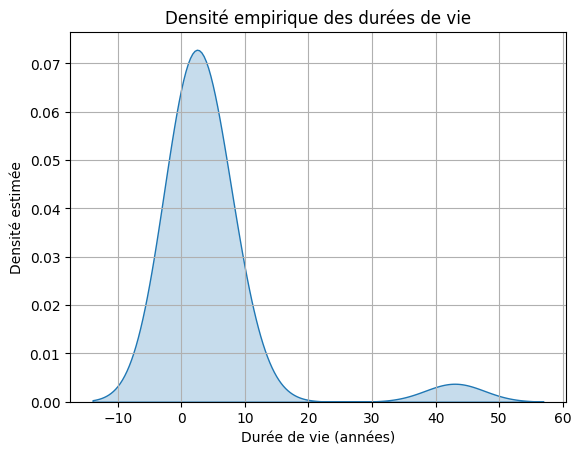

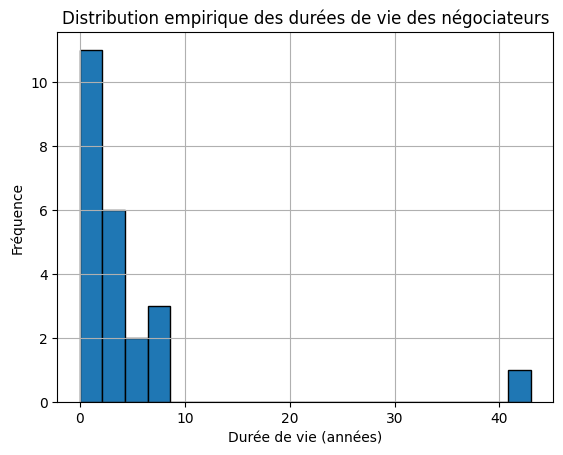

Min : 0.0027378507871321013
Max : 43.0
Moyenne : 4.5071868583162225
Médiane : 2.2477754962354553
Écart-type : 8.529779072855245


In [14]:
duree_de_vie_negos["duree_de_vie"] = duree_de_vie_negos["neg_date_creation"] - duree_de_vie_negos["neg_date_archive"]

liste_duree_de_vie_negos = duree_de_vie_negos["duree_de_vie"].tolist()
liste_duree_de_vie_negos = [x for x in liste_duree_de_vie_negos if x is not NaT]
liste_duree_de_vie_negos = [x for x in liste_duree_de_vie_negos if pd.notna(x) and x != pd.Timedelta(0)]
liste_duree_de_vie_negos = [x.days / 365.25 for x in liste_duree_de_vie_negos]
liste_duree_de_vie_negos = [np.abs(x) for x in liste_duree_de_vie_negos]
liste_duree_de_vie_negos = [x if x < 43 else 43 for x in liste_duree_de_vie_negos]

sns.kdeplot(liste_duree_de_vie_negos, fill=True)
plt.xlabel("Durée de vie (années)")
plt.ylabel("Densité estimée")
plt.title("Densité empirique des durées de vie")
plt.grid(True)
plt.show()

plt.hist(liste_duree_de_vie_negos, bins=20, edgecolor='black')
plt.xlabel("Durée de vie (années)")
plt.ylabel("Fréquence")
plt.title("Distribution empirique des durées de vie des négociateurs")
plt.grid(True)
plt.show()

valeurs = np.array(liste_duree_de_vie_negos)

print("Min :", np.min(valeurs))
print("Max :", np.max(valeurs))
print("Moyenne :", np.mean(valeurs))
print("Médiane :", np.median(valeurs))
print("Écart-type :", np.std(valeurs))

In [15]:
# On supprime ces datasets qui ne pourront donc pas servir

del liste_duree_de_vie_negos
del duree_de_vie_negos
gc.collect()

4666

**Problème : l'échantillon dont on dispose dans la BDD ne représente que le temps que les négociateurs restent inscrits sur LogiPro... En réalité, ce serait très étonnant qu'ils ne restent négociateurs pour la grande majorité qu'un an...**

Aucune étude existante ne donne une distribution de l'ancienneté des négociateurs avant de partir à la retraire ou de changer de métier. 

On n'aura donc aucun moyen de vérifier si les résultats du modèle en termes de longévité des négociateurs dans leur métier représentent bien la réalité. 

**Deuxième estimation : il faut attribuer la probabilité, quand un nouveau négociateur entre sur le marché, qu'il rejoigne une agence déjà existante, ou qu'il fonde sa propre agence**

On peut supposer que plus il y a d'agences actives dans sa région, plus le nouveau négociateur aura tendance à rejoindre une agence existante plutôt que de créer la sienne. 

On suppose une décroissante exponentielle de la probabilité de fonder son agence avec le nombre d'agences existantes. (Loi exponentielle de paramètre 1)

**Données à produire : les lieux où se trouvent les agences**

In [16]:
# # Cellule commentée pcq on l'a exécutée une fois et téléchargé l'excel qui en résulte
# # (Sinon l'exécution dure une vingtaine de minutes)

# # On dresse la liste des noms de colonnes liées aux agences
# colonnes_agence = ['agence_id', 'agence_nom', 'agence_ville', 'agence_adresse', 'agence_code_postal']

# # On supprime les doublons pour avoir une seule ligne par agence
# localisations_agences = agences_negociateurs[colonnes_agence].drop_duplicates().reset_index(drop=True)

# print(localisations_agences.columns)
# print(localisations_agences.shape)

# # On forme une chaîne de caractères qui donne l'adresse de l'agence en entier, sous la forme adresse + ville
# localisations_agences['adresse_complete'] = (
#     localisations_agences['agence_adresse'].astype(str) + ", " +
#     localisations_agences['agence_code_postal'].astype(str) + " " +
#     localisations_agences['agence_ville'].astype(str) + ", France"
# )

# print(localisations_agences.shape)

# # Pour obtenir les coordonnées géographiques des agences, nécessaires à l'affichage d'une carte
# # Compter 10 minutes d'exécution

# geolocator = Nominatim(user_agent="geocodage_agences")

# # On se définit une fonction qui prend en argument une adresse complète et qui retourne latitude et longitude
# def geocode_adresse(adresse, retries=3):
#     for attempt in range(retries):
#         try:
#             location = geolocator.geocode(adresse, timeout = 15)
#             if location:
#                 return pd.Series([location.latitude, location.longitude])
#             else:
#                 return pd.Series([None, None])
#         except (GeocoderTimedOut, GeocoderUnavailable) as e:
#             print(f"Essai {attempt+1}/{retries} timeout pour {adresse}, retrying...")
#             time.sleep(2)  # pause avant retry, ça plante si on met un temps de pause trop court
#         except Exception as e:
#             print(f"Erreur inattendue pour {adresse} : {e}")
#             break
#     return pd.Series([None, None])

# # On applique la fonction à toutes les agences
# latitudes = []
# longitudes = []

# i = 0
# for adresse in localisations_agences['adresse_complete'] :
#     i += 1
#     lat, lon = geocode_adresse(adresse)
#     latitudes.append(lat)
#     longitudes.append(lon)
#     print(f"Plus que {localisations_agences.shape[0] - i} coordonnées à caculer")
#     time.sleep(1.3) # Pour éviter d'être bloqué par le service. Si pb de timeout, augmenter le timesleep

# # Ajouter les colonnes au DataFrame
# localisations_agences['latitude'] = latitudes
# localisations_agences['longitude'] = longitudes

# localisations_agences.to_excel("localisations_agences.xlsx", index=False)

localisations_agences = pd.read_excel("localisations_agences.xlsx")

localisations_agences = localisations_agences[localisations_agences["agence_nom"] != "Marion"]
localisations_agences = localisations_agences[localisations_agences["agence_nom"] != "Valérie"]
localisations_agences = localisations_agences[localisations_agences["agence_nom"] != "ARTHUR LOYD LOGISTIQUE"]
localisations_agences = localisations_agences[localisations_agences["agence_nom"] != "DBX Test new descro"]
localisations_agences = localisations_agences[localisations_agences["agence_nom"] != "Agence Commerce"]
localisations_agences = localisations_agences[localisations_agences["agence_nom"] != "Agence Activité"]
localisations_agences = localisations_agences[localisations_agences["agence_nom"] != "Colliers Confidentiel"]
localisations_agences = localisations_agences[localisations_agences["agence_id"] != 0]

print(localisations_agences.shape)
print(localisations_agences.columns)

(272, 8)
Index(['agence_id', 'agence_nom', 'agence_ville', 'agence_adresse',
       'agence_code_postal', 'adresse_complete', 'latitude', 'longitude'],
      dtype='object')


In [17]:
# Pour la suite, c'est important que les données soient dans un géodataframe (gdf)
# Donc on convertit le dataframe des agences et celui des offres en géodataframes

gdf_agences = gpd.GeoDataFrame(localisations_agences, geometry=gpd.points_from_xy(localisations_agences.longitude, localisations_agences.latitude), crs="EPSG:4326")
gdf_offres = gpd.GeoDataFrame(lots_adresses, geometry=gpd.points_from_xy(lots_adresses.adr_plan_x, lots_adresses.adr_plan_y), crs="EPSG:4326")

# On reprojette en Web Mercator 
gdf_agences = gdf_agences.to_crs(epsg=3857)
gdf_offres = gdf_offres.to_crs(epsg=3857)

print(gdf_agences.shape)
print(gdf_offres.shape)

(272, 9)
(2242533, 11)


**Statistique descriptive : la carte des lots et des agences** (monde puis France)

In [18]:
# # On commente donc ici pour s'économiser du temps
# # Il s'agit d'une carte du monde qui donne les lieux où se trouvent les offres et les agences

# fig, ax = plt.subplots(figsize=(12, 12))

# gdf_offres.plot(ax=ax, color='red', markersize=10, label='Offres')
# gdf_agences.plot(ax=ax, color='blue', markersize=20, label='Agences')

# ax.set_xlim(-20037508, 20037508)
# ax.set_ylim(-8037508, 18037508)

# # Ajouter le fond de carte
# ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
# plt.legend()
# ax.set_axis_off()

# plt.title("Localisation des agences (bleu) et des offres (rouge)")
# plt.show()

In [19]:
# # On commente donc ici pour s'économiser du temps
# # Il s'agit d'une carte de France qui donne les lieux où se trouvent les offres et les agences

# fig, ax = plt.subplots(figsize=(12, 12))

# gdf_offres.plot(ax=ax, color='red', markersize=2, label='Offres')
# gdf_agences.plot(ax=ax, color='blue', markersize=20, label='Agences')

# # Définir les limites France métropolitaine
# # Limites France métropolitaine en EPSG:3857
# ax.set_xlim(-560000, 1200000)
# ax.set_ylim(5000000, 6700000)

# # Ajouter le fond de carte
# ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
# plt.legend()
# ax.set_axis_off()
# plt.title("Localisation des agences (bleu) et des offres (rouge)")
# plt.show()

In [20]:
# Pour la suite, on ne garde que ce qui est en France métropolitaine (en degrés WGS84)
lots_adresses = lots_adresses[
    (lots_adresses['adr_plan_x'] >= -5.0) & (lots_adresses['adr_plan_x'] <= 10.0) &  # longitudes
    (lots_adresses['adr_plan_y'] >= 41.0) & (lots_adresses['adr_plan_y'] <= 52.0)    # latitudes
].copy()

print(f"Nombre de lots après filtrage : {len(lots_adresses)}")

Nombre de lots après filtrage : 2133958


**Estimation des processus de Poisson de création de nouvelles offres et de nouvelles transactions**

Quelques explications : on estime ici un "processus de Poisson". Il s'agit mathématiquement dans notre cas de l'étude dates aléatoires auxquelles vont avoir lieu des événements ponctuels, comme la publication d'une offre ou la signature d'une transaction. Plusieurs grandeurs caractérisent un processus de Poisson, la plus "pratique" étant son intensité. On la note $\lambda$, et elle représente l'inverse du temps à attendre en moyenne théorique avant l'occurence du prochain événement. 

Comme dans un processus de Poisson, le temps d'attente entre l'occurence de deux événements suit une loi exponentielle, $\lambda$ n'est autre que l'inverse de la moyenne du temps d'attente entre deux événements.

In [21]:
# On converti en format datetime
offres_dates_creation['off_date_creation'] = pd.to_datetime(offres_dates_creation['off_date_creation'])

# On trie par date
offres_dates_creation = offres_dates_creation.sort_values('off_date_creation').reset_index(drop=True)

# On calcule les intervalles entre les créations successives d'offres (en jours, comme la granularité du modèle sera la journée)
intervalles = offres_dates_creation['off_date_creation'].diff().dropna().dt.total_seconds() / (3600 * 24)

# On estime maintenant le paramètre lambda
lambda_estime = 1 / intervalles.mean()

print(f"Taux de création d'offres estimé : {lambda_estime} offres par jour")

# # Visualisation
# # On la garde commentée parce que vu l'intensité de 134... On ne va rien voir, c'est énorme
# x = np.linspace(0, intervalles.max(), 200)
# plt.figure(figsize=(10,6))
# plt.hist(intervalles, bins=50, density=True, alpha=0.6, color='skyblue', label="Intervalles observés")
# plt.plot(x, expon.pdf(x, scale=1/lambda_estime), 'r-', lw=2, label=f"Loi exponentielle (λ={lambda_estime:.4f})")
# plt.title("Intervalles entre créations d'offres — Processus de Poisson estimé")
# plt.xlabel("Intervalle entre deux offres (jours)")
# plt.ylabel("Densité de probabilité")
# plt.legend()
# plt.grid(True)
# plt.show()

# On sauvegarde le paramètre lambda
modele_poisson = {'lambda': lambda_estime}

with open("processus_poisson_offres.pkl", "wb") as f :
    pickle.dump(modele_poisson, f)

print("Processus de Poisson sauvegardée dans 'processus_poisson_offres.pkl'")

Taux de création d'offres estimé : 149.521257283148 offres par jour
Processus de Poisson sauvegardée dans 'processus_poisson_offres.pkl'


In [22]:
# Et on fait la même chose avec les transactions

# On prépare les intervalles entre deux transactions
dates_transac = dates_transac.sort_values('tra_date_signature')
dates = pd.to_datetime(dates_transac['tra_date_signature']).values
intervalles_jours = np.diff(dates) / np.timedelta64(1, 'D')  # en jours

# On estime l'intensité de la même manière que précédemment
lambda_estime = 1 / np.mean(intervalles_jours)
print(f"Lambda estimé : {lambda_estime}")

# Sauvegarde
with open("poisson_transactions.pkl", "wb") as f :
    pickle.dump(lambda_estime, f)

print("Processus de Poisson sauvegardé dans 'poisson_transactions.pkl'")

Lambda estimé : 27.49393190662326
Processus de Poisson sauvegardé dans 'poisson_transactions.pkl'


**On estime maintenant la densité spatiale des lots**

In [23]:
# Toujours important avant de manipuler un géodataframe : on le convertit dans le bon format si il ne l'est
# pas déjà, et on projette dans le bon système de coordonnées pour ne pas faire de bêtises; 
# Ici, système de coordonnées : Web Mercator 

gdf_offres = gpd.GeoDataFrame(lots_adresses, geometry=gpd.points_from_xy(lots_adresses.adr_plan_x, lots_adresses.adr_plan_y), crs="EPSG:4326")
gdf_offres = gdf_offres.to_crs(epsg=3857)

print(gdf_offres.shape)

(2133958, 11)


In [24]:
# Supprimer la colonne si elle existe déjà

if 'lot_actif' in gdf_offres.columns :
    gdf_offres.drop(columns='lot_actif', inplace=True)

# Si on essaye d'ajouter une colonne lot_actif à partir d'une jointure avec un autre dataframe alors 
# qu'elle existe déjà, on va se retrouver avec des colonnes nommées lot_actif_x et lot_actif_y
# avec _x pour celle qui vient du dataframe de gauche dans la jointure et _y pour celui de droite
# Dans une version précédente du code, j'ai rencontré des problèmes inexpliqués avec les noms de colonnes
# et des colonnes qui se multipliaient, donc je préfère garder le test ci-dessous au cas où

if 'lot_actif_x' in gdf_offres.columns :
    gdf_offres.drop(columns='lot_actif_x', inplace=True)
if 'lot_actif_y' in gdf_offres.columns :
    gdf_offres.drop(columns='lot_actif_y', inplace=True)

In [25]:
# On ne garde que les lots actifs
# Maj : on a déjà filtré plus haut, normalement cette cellule ne fait rien

lots_actifs = lots_infos_basiques.groupby('lot_id', as_index=False)['lot_actif'].max()
gdf_offres = gdf_offres.merge(lots_actifs, on='lot_id', how='left')

# Filtrage : uniquement les points actifs
gdf_offres = gdf_offres[gdf_offres['lot_actif'] == 1]

gdf_offres = gdf_offres.to_crs(epsg=3857)

Quelques détails sur l'estimateur KDE (kernel estimator density) sans rentrer en détail dans les maths : 

Une densité de probabilité, c'est un ensemble de nombre (de probabilités, associées à des événements, des points, des lieux, peu importe). Par exemple, quand on lance un dé, la densité de probabilité est donnée par 1/6 pour le résultat 1, 1/6 pour le résultat 2, ... et un 1/6 pour le résultat 6. La somme des probabilités fait 1 (1/6 + 1/6 + 1/6 + 1/6 + 1/6 + 1/6 = 1).Autrement dit, quand on lance un dé, avec probabilité de 1, ou de 100%, on obtiendra un résultat. 

On peut faire la même chose sur un espace en deux dimensions, comme la France par exemple. On souhaite définir une densité des lots. On part du principe que ce qu'on observe (la position des lots à pourvoir sur le territoire) est la réalisation de génération de lots à des lieux aléatoires en France selon une certaine distribution de probabilités, que l'on cherche à estimer.

L'estimateur KDE effectue ce travail de la manière suivante : on découpe le territoire en un quadrillage dont on contrôle la largeur des mailles. Ici, on a retenu une largeur de 1000 mètres sur 1000 mètres, et en saisissant la distance à laquelle la présence d'un lot influe sur la probabilité de trouver un autre lot. On retient 3 kilomètres : la présence d'un lot augmente la probabilité d'en trouver un autre dans un rayon de 3 kilomètres autour de lui, mais ne dit rien sur la probabilité d'en trouver au-delà. Si on souhaite poser un lot de manière aléatoire sur la carte de la France selon la loi de probabilité en deux dimensions sous-jacente, il faut connaître la probabilité à attribuer à chaque case du quadrillage. Et de la même manière que quand on lance un dé on est certain d'obtenir un résultat, quand on place un lot en France, on est sûr de le placer en France : la somme des probabilités de chaque case du quadrillage fait 1. 

Une fois cette estimation faite, on sera en mesure de simuler l'arrivée sur le marché de nouvelles offres en suivant la loi de probabilité sous-jacente. En ajoutant à cela l'estimation de l'intensité du processus de Poisson précédente, on sera aussi en mesure de simuler les dates d'arrivée sur le marché des nouvelles offres. 

Traitement de la région : Île-de-France (11)


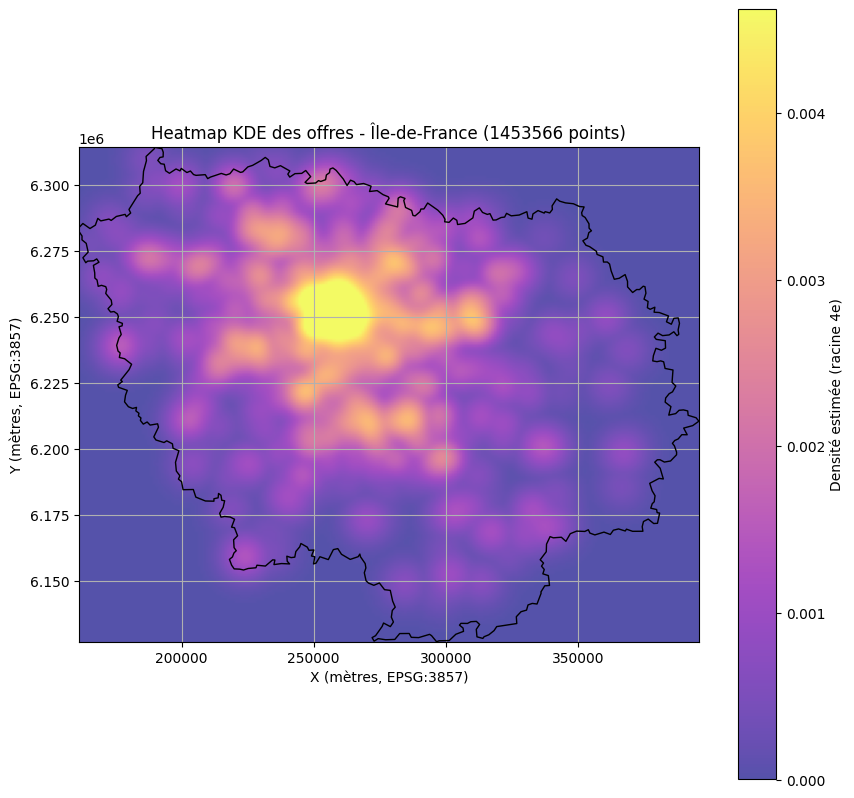

Traitement de la région : Centre-Val de Loire (24)


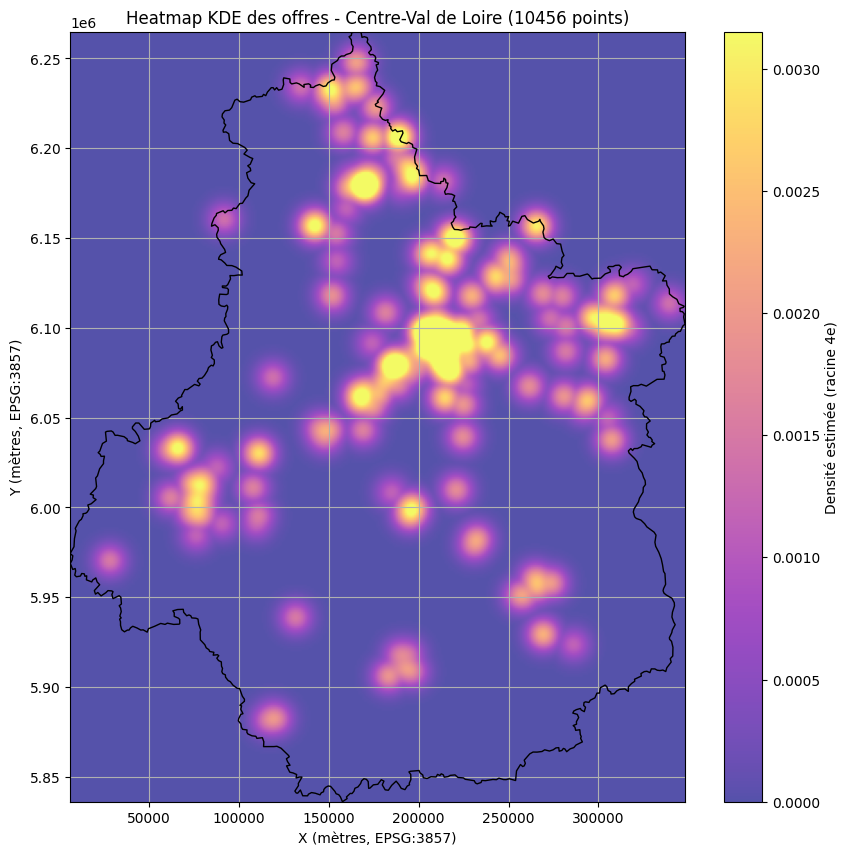

Traitement de la région : Bourgogne-Franche-Comté (27)


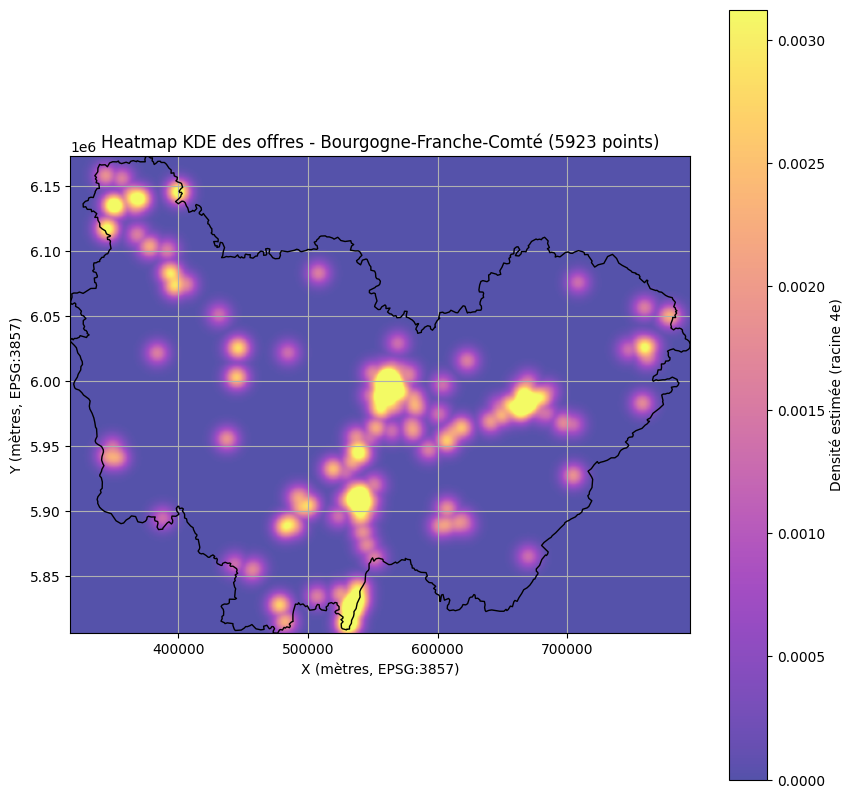

Traitement de la région : Normandie (28)


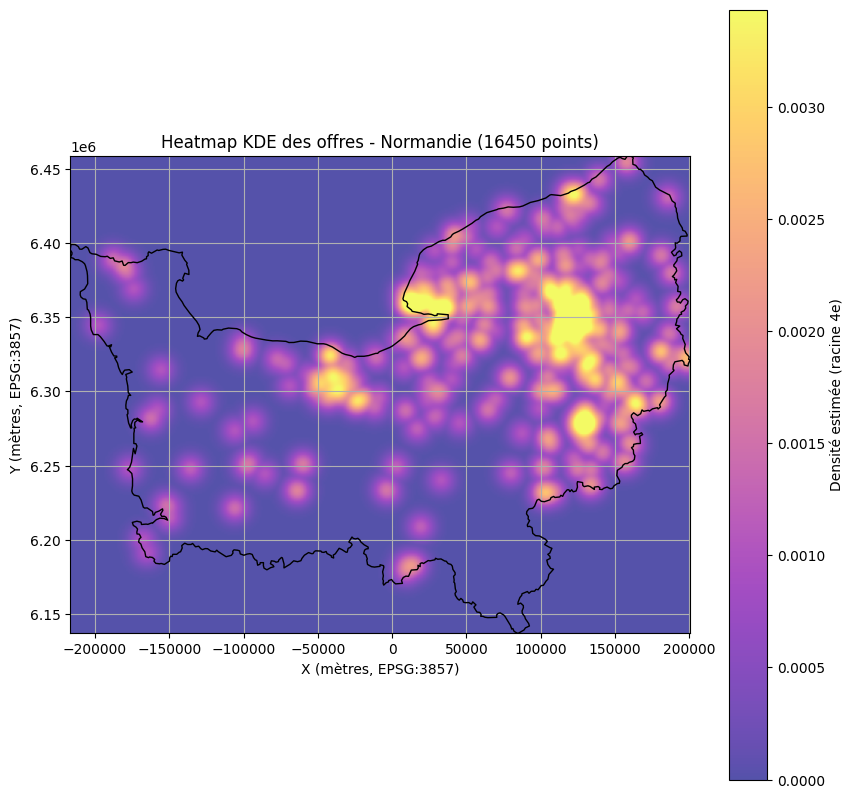

Traitement de la région : Hauts-de-France (32)


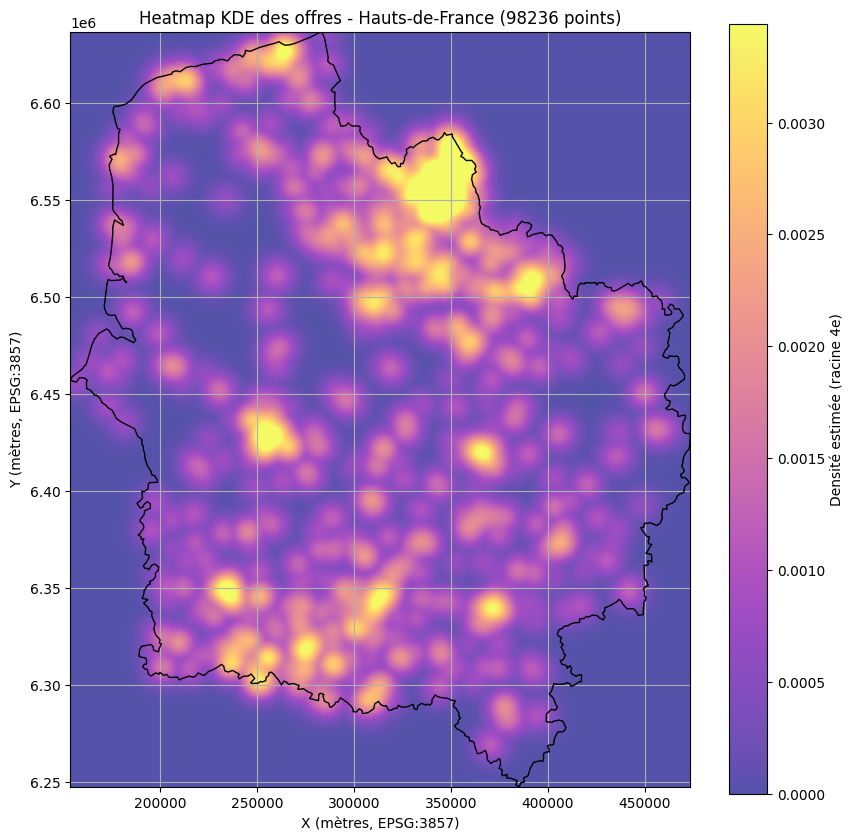

Traitement de la région : Grand Est (44)


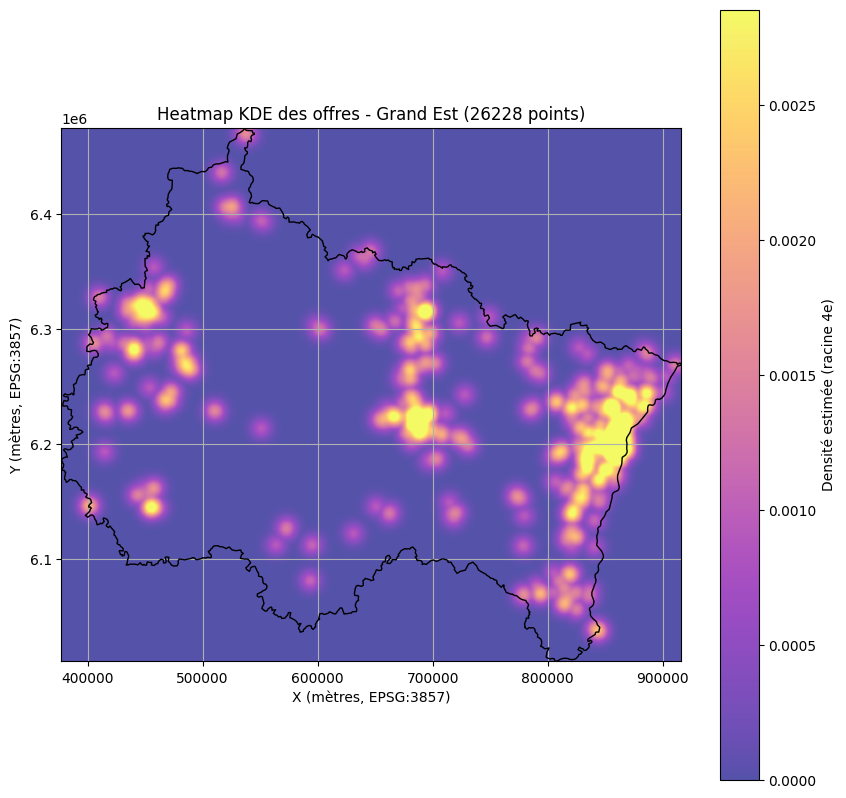

Traitement de la région : Pays de la Loire (52)


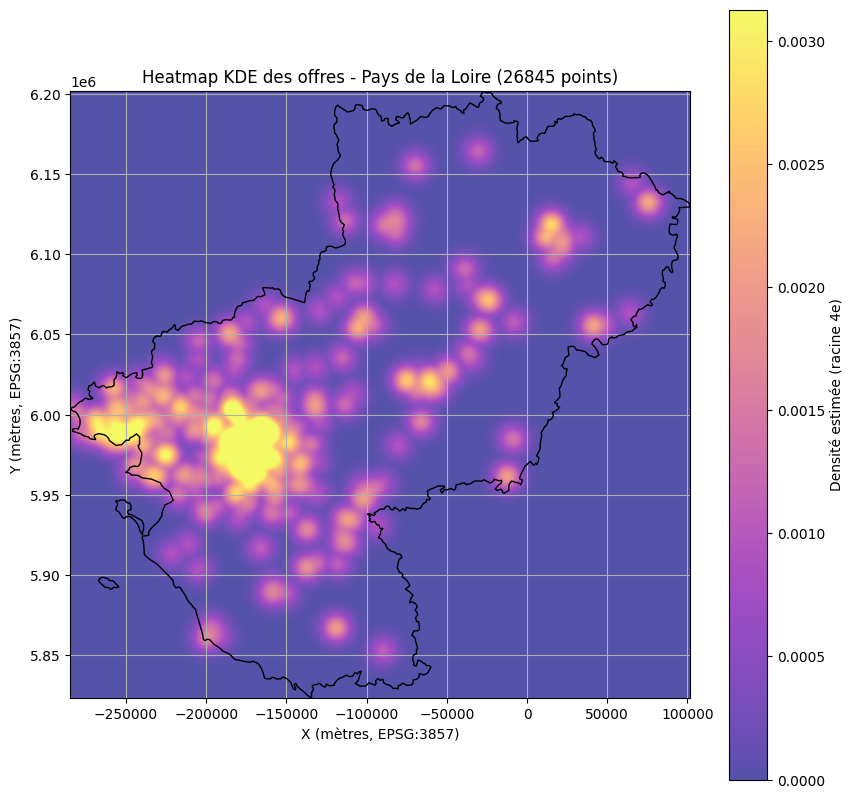

Traitement de la région : Bretagne (53)


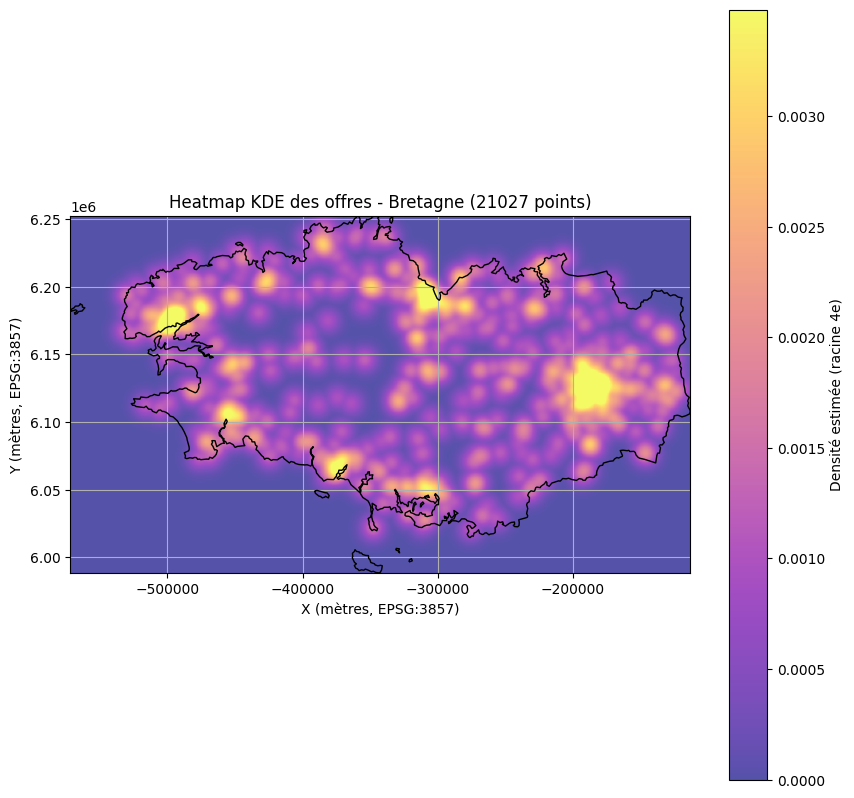

Traitement de la région : Nouvelle-Aquitaine (75)


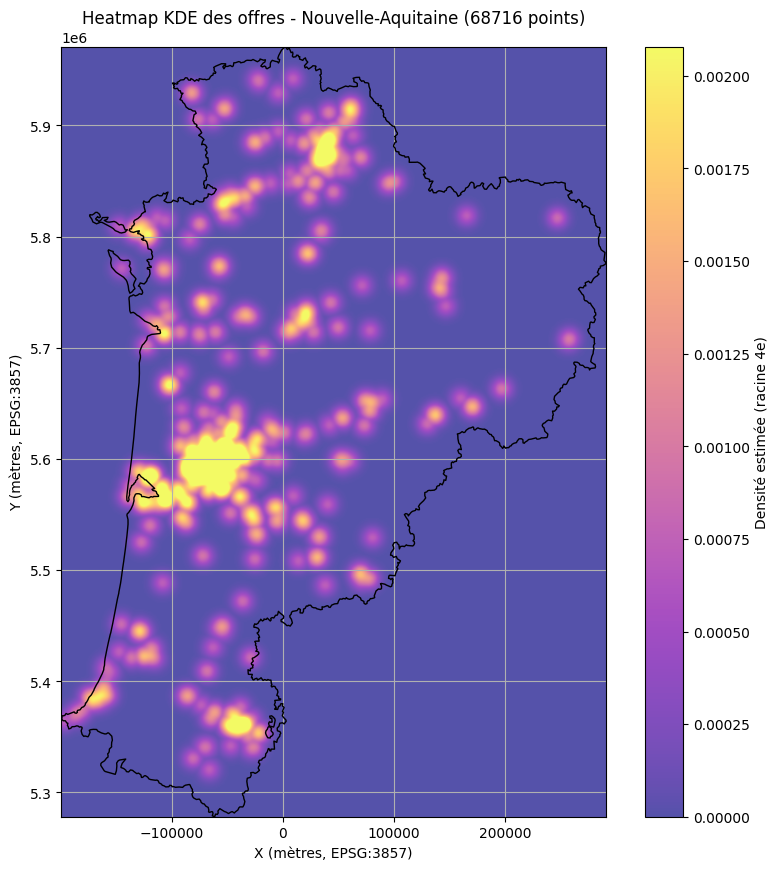

Traitement de la région : Occitanie (76)


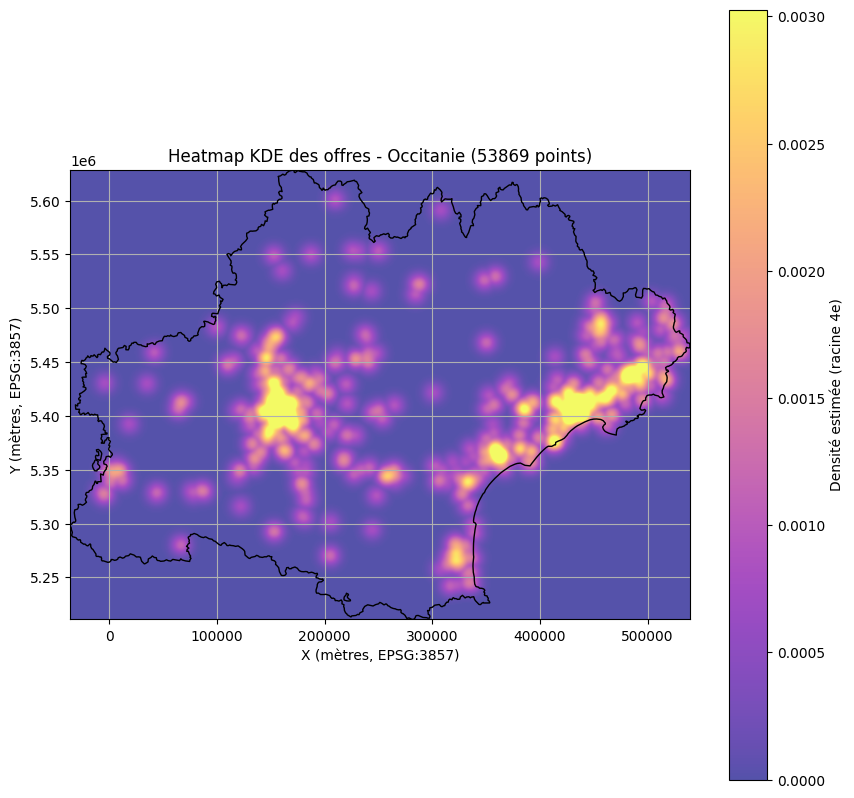

Traitement de la région : Auvergne-Rhône-Alpes (84)


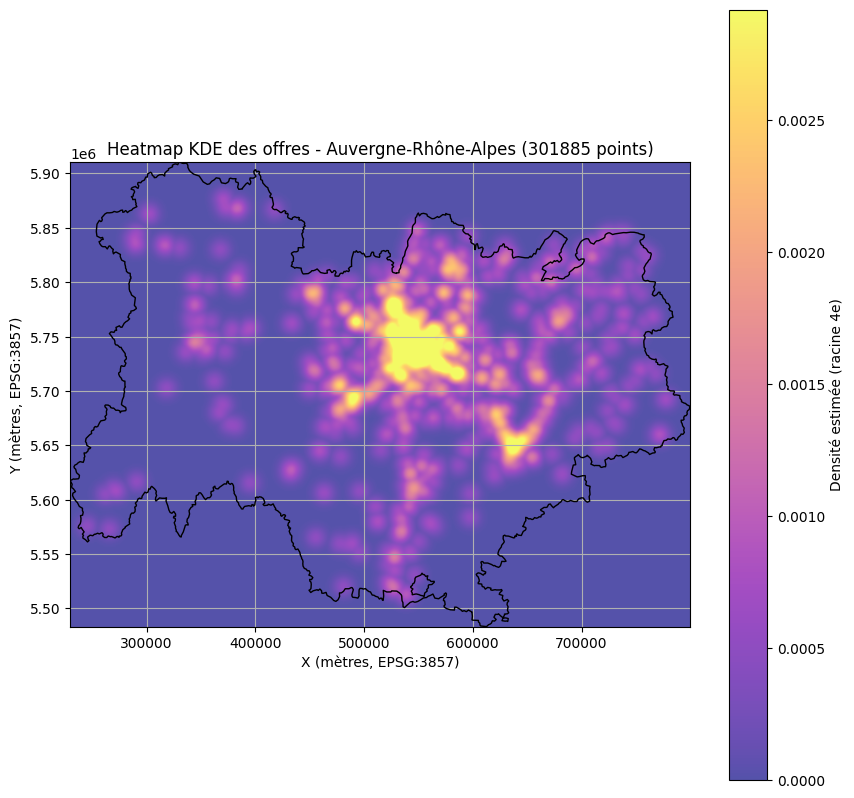

Traitement de la région : Provence-Alpes-Côte d'Azur (93)


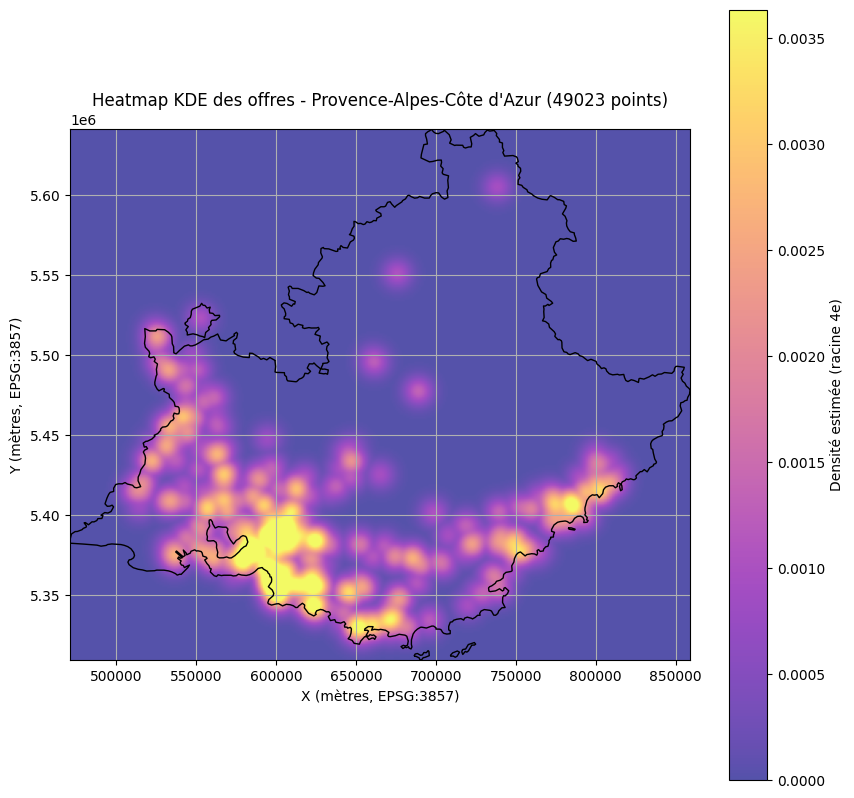

Traitement de la région : Corse (94)


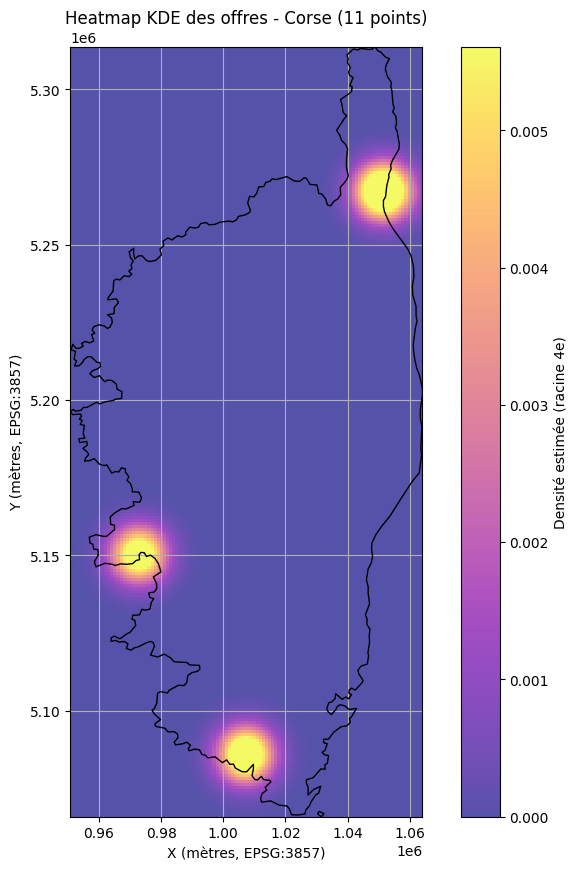

In [26]:
# Cette première cellule d'affichage de la densité est à but illustratif : on affiche région par région
# pour visualiser de près les résultats sur chaque zone géographique

# On charge les régions françaises 
gdf_regions = gpd.read_file("https://france-geojson.gregoiredavid.fr/repo/regions.geojson")

# On ne garde que les régions métropolitaines
# Liste des codes INSEE des régions métropolitaines
codes_metropole = ['11', '24', '27', '28', '32', '44', '52', '53', '75', '76', '84', '93', '94']
gdf_regions = gdf_regions[gdf_regions['code'].isin(codes_metropole)].copy()

# Assurer la projection EPSG:3857 pour tout le monde (projection métrique)
# Normalement déjà fait plus haut mais on n'est jamais trop prudent
gdf_regions = gdf_regions.to_crs(epsg=3857)
gdf_offres = gdf_offres.to_crs(epsg=3857)

# Paramètres KDE (kernel density estimator)
grid_size = 1000 # résolution de la grille : on quadrille la France avec des carrés de 1000m sur 1000m
bandwidth = 3000 # largeur de bande KDE : la présence d'un lot influe sur la densité à 3km alentours

# Fonction pour générer la heatmap pour une région donnée
def plot_kde_region(region_gdf, region_name) :

    # On filtre les points dans la région en question
    mask = gdf_offres.geometry.within(region_gdf.geometry.iloc[0])
    gdf_region_points = gdf_offres[mask].copy()

    if len(gdf_region_points) == 0 :
        # Normalement ça n'arrive pas mais au moins si il y a un problème dans les données on s'en rendra compte
        print(f"Aucun point dans la région {region_name}, skip")
        return

    # Coordonnées des points
    coords = np.array([(pt.x, pt.y) for pt in gdf_region_points.geometry])

    # Définir la grille sur les bounds de la région
    x_min, y_min, x_max, y_max = region_gdf.total_bounds
    x_grid = np.arange(x_min, x_max, grid_size)
    y_grid = np.arange(y_min, y_max, grid_size)
    xv, yv = np.meshgrid(x_grid, y_grid)
    grid_coords = np.vstack([xv.ravel(), yv.ravel()]).T

    # kernel = gaussian : la décroissance de la probabilité de croiser un nouveau lot avec la distance
    # est gaussienne (exp{-x^2}), décroissance rapide avec la distance
    # metric = euclidean : on reste dans une géométre plate, appliquer une correction pour considérer des 
    # distances sur une sphère (on admet que la Terre n'est pas plate hein) n'apporterait pas grand chose
    # en termes de précision à l'échelle de la France
    kde = KernelDensity(bandwidth=bandwidth, kernel='gaussian', metric='euclidean')
    kde.fit(coords)

    # Découpage pour parallélisation
    n_jobs = -1 # pour utiliser toute la CPU
    chunk_size = int(len(grid_coords) / (4 * os.cpu_count())) or 1

    def process_chunk(chunk):
        return kde.score_samples(chunk)

    chunks = [grid_coords[i:i + chunk_size] for i in range(0, len(grid_coords), chunk_size)]
    log_densities_chunks = Parallel(n_jobs=n_jobs)(delayed(process_chunk)(chunk) for chunk in chunks)

    log_density = np.concatenate(log_densities_chunks)
    density = np.exp(log_density).reshape(len(y_grid), len(x_grid))

    # Transformation en racine 4e pour la couleur, sinon l'échelle est trop disparate : ultra concentration 
    # en région parisienne rend le reste de la carte tout noir
    density_root = density ** 0.25

    # Paramètres d'affichage pour cohérence et lisibilité des couleurs sur la carte
    vmin = np.percentile(density_root, 5)
    vmax = np.percentile(density_root, 99)

    fig, ax = plt.subplots(figsize=(10, 10))
    heatmap = ax.imshow(
        density_root,
        extent=(x_min, x_max, y_min, y_max),
        origin='lower',
        cmap='plasma',
        alpha=0.7,
        vmin=vmin,
        vmax=vmax
    )

    # Contours de la région
    region_gdf.boundary.plot(ax=ax, color='black', linewidth=1)

    plt.colorbar(heatmap, ax=ax, label="Densité estimée (racine 4e)")
    ax.set_title(f"Heatmap KDE des offres - {region_name} ({len(gdf_region_points)} points)")
    ax.set_xlabel("X (mètres, EPSG:3857)")
    ax.set_ylabel("Y (mètres, EPSG:3857)")
    plt.grid(True)
    plt.show()

# Boucle sur toutes les régions métropolitaines
for idx, region in gdf_regions.iterrows():
    print(f"Traitement de la région : {region['nom']} ({region['code']})")
    plot_kde_region(gdf_regions.loc[[idx]], region['nom'])

Calcul KDE pour Île-de-France (11)
Calcul KDE pour Centre-Val de Loire (24)
Calcul KDE pour Bourgogne-Franche-Comté (27)
Calcul KDE pour Normandie (28)
Calcul KDE pour Hauts-de-France (32)
Calcul KDE pour Grand Est (44)
Calcul KDE pour Pays de la Loire (52)
Calcul KDE pour Bretagne (53)
Calcul KDE pour Nouvelle-Aquitaine (75)
Calcul KDE pour Occitanie (76)
Calcul KDE pour Auvergne-Rhône-Alpes (84)
Calcul KDE pour Provence-Alpes-Côte d'Azur (93)
Calcul KDE pour Corse (94)
Export parquet terminé.


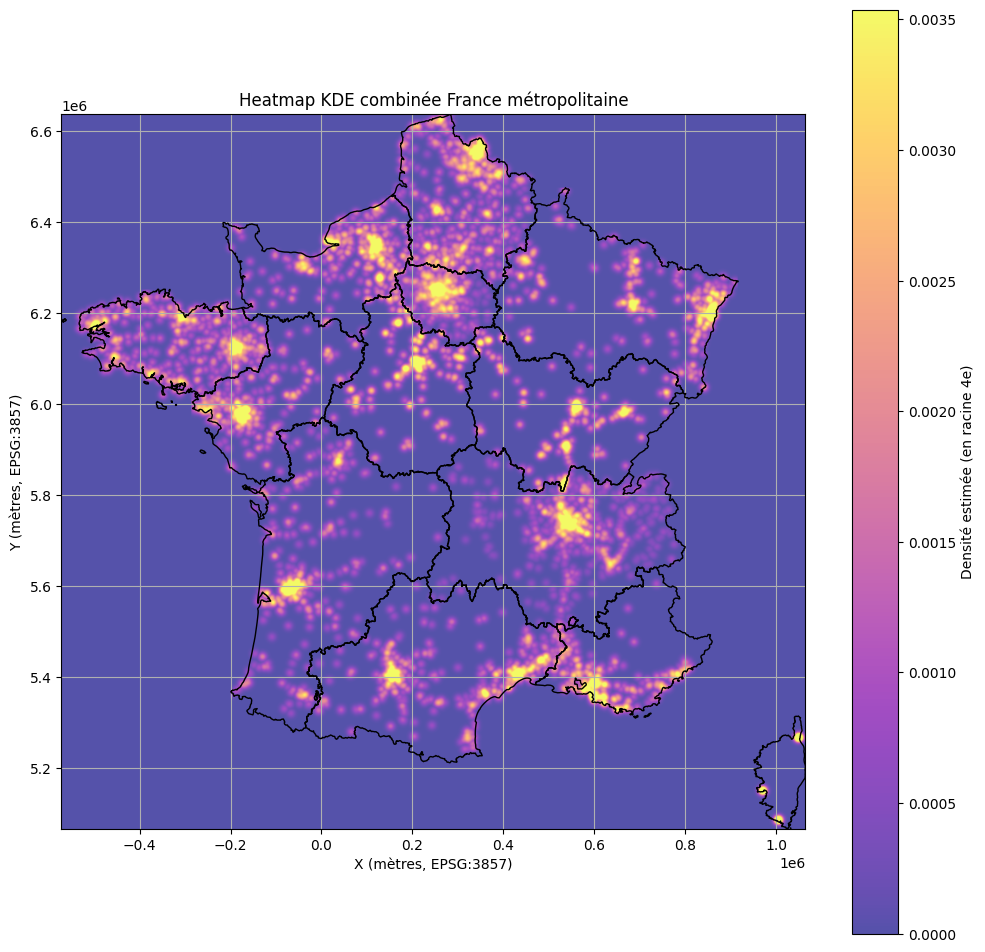

In [27]:
# Cette deuxième cellule de calcul et affichage de la desnité est plus fonctionnelle : on assemble 
# les résultats par régions et les morceaux de carte pour produire une carte de la France et une fichier 
# réutilisable par la suite qui sauvegarde la densité spatiale estimée

# On charge les régions métropolitaines
gdf_regions = gpd.read_file("https://france-geojson.gregoiredavid.fr/repo/regions.geojson")
codes_metropole = ['11', '24', '27', '28', '32', '44', '52', '53', '75', '76', '84', '93', '94']
gdf_regions = gdf_regions[gdf_regions['code'].isin(codes_metropole)].copy()
gdf_regions = gdf_regions.to_crs(epsg=3857)

# Paramètres KDE
grid_size = 1000 # résolution (m)
bandwidth = 3000 # largeur de bande (m aussi)

def compute_kde_region(region_gdf, region_name, gdf_offres):
    # On filtre par région
    mask = gdf_offres.geometry.within(region_gdf.geometry.iloc[0])
    gdf_region_points = gdf_offres[mask].copy()

    if len(gdf_region_points) == 0:
        print(f"Aucun point dans la région {region_name}, skip")
        return None

    coords = np.array([(pt.x, pt.y) for pt in gdf_region_points.geometry])

    # Grille régionale
    x_min, y_min, x_max, y_max = region_gdf.total_bounds
    x_grid = np.arange(x_min, x_max + grid_size, grid_size)
    y_grid = np.arange(y_min, y_max + grid_size, grid_size)
    xv, yv = np.meshgrid(x_grid, y_grid)
    grid_coords = np.vstack([xv.ravel(), yv.ravel()]).T

    # Mêmes remarques que dans la cellule précédente
    kde = KernelDensity(bandwidth=bandwidth, kernel='gaussian', metric='euclidean')
    kde.fit(coords)

    # Parallélisation
    n_jobs = -1
    chunk_size = int(len(grid_coords) / (4 * os.cpu_count())) or 1

    def process_chunk(chunk):
        return kde.score_samples(chunk)

    chunks = [grid_coords[i:i + chunk_size] for i in range(0, len(grid_coords), chunk_size)]
    log_densities_chunks = Parallel(n_jobs=n_jobs)(delayed(process_chunk)(chunk) for chunk in chunks)

    log_density = np.concatenate(log_densities_chunks)
    density = np.exp(log_density).reshape(len(y_grid), len(x_grid))

    # Retourner dataframe pour assemblage et données pour affichage
    density_df = pd.DataFrame({
        'x': xv.ravel(),
        'y': yv.ravel(),
        'density': density.ravel(),
        'region': region_name
    })
    return density_df, (x_min, x_max, y_min, y_max)

# Liste pour concaténer
list_density_dfs = []
bounds_list = []

# Boucle sur régions
for idx, region in gdf_regions.iterrows():
    print(f"Calcul KDE pour {region['nom']} ({region['code']})")
    result = compute_kde_region(gdf_regions.loc[[idx]], region['nom'], gdf_offres)
    if result is not None:
        density_df, bounds = result
        list_density_dfs.append(density_df)
        bounds_list.append(bounds)

# On concatène les données par région
density_all = pd.concat(list_density_dfs, ignore_index=True)

# Export rapide et efficace
density_all.to_parquet("kde_france_metropole.parquet", index=False, engine="fastparquet")
print("Export parquet terminé.")

# Affichage heatmap combinée

# Définition des bornes
x_min_total = min(b[0] for b in bounds_list)
x_max_total = max(b[1] for b in bounds_list)
y_min_total = min(b[2] for b in bounds_list)
y_max_total = max(b[3] for b in bounds_list)

# On crée une grille commune pour l'affichage
x_grid_total = np.arange(x_min_total, x_max_total + grid_size, grid_size)
y_grid_total = np.arange(y_min_total, y_max_total + grid_size, grid_size)
xv_total, yv_total = np.meshgrid(x_grid_total, y_grid_total)

# On crée une matrice vide (un coeff = 1km^2... C'est une grosse matrice)
density_matrix = np.zeros_like(xv_total, dtype=float)

# On remplit les coefficients de la matrice par régions
for region_name in density_all['region'].unique():
    df_region = density_all[density_all['region'] == region_name]
    # Trouver indices correspondants dans la grille globale
    ix = ((df_region['x'] - x_min_total) / grid_size).round().astype(int)
    iy = ((df_region['y'] - y_min_total) / grid_size).round().astype(int)
    density_matrix[iy, ix] += df_region['density'].values

# Transformation racine 4e pour les couleurs
density_root = density_matrix ** 0.25
vmin = np.percentile(density_root[density_root>0], 5)
vmax = np.percentile(density_root[density_root>0], 99)

fig, ax = plt.subplots(figsize=(12,12))
heatmap = ax.imshow(
    density_root,
    extent=(x_min_total, x_max_total, y_min_total, y_max_total),
    origin='lower',
    cmap='plasma',
    alpha=0.7,
    vmin=vmin,
    vmax=vmax
)

# On affiche les contours des régions
gdf_regions.boundary.plot(ax=ax, color='black', linewidth=1)

plt.colorbar(heatmap, ax=ax, label="Densité estimée (en racine 4e)")
ax.set_title("Heatmap KDE combinée France métropolitaine")
ax.set_xlabel("X (mètres, EPSG:3857)")
ax.set_ylabel("Y (mètres, EPSG:3857)")
plt.grid(True)
plt.show()

Attention, à noter que sur l'affichage, on dirait que dans chaque région il y a une ville aussi dense que Paris. Ce n'est pas le cas ! On a calculé une densité par région, puis on a assemblé toutes les visualisations pour ne constituer plus qu'une seule carte. C'était la seule solution pour voir d'autres villes que Paris, sinon la densité de Paris écrase toutes les autres, même en échelle racine 4e.

In [28]:
# Première chose à faire : remise à l'échelle de la densité estimée des lots
# (jusque là, ça somme à 1 sur chaque région au lieu de sommer à 1 sur tout la France : on va donc
# repondérer correctement la densité sur chaque région en fonction du nombre de lots, et finir par normaliser)

# Pas mal de redits dans cette cellule, elle vient d'un autre notebook à la base, mais ça fonctionne
# comme ça, et flmme d'investiguer pour voir ce qu'on peut supprimer tout ça pour garder 20 secondes...

# On converti en géodataframe
gdf_offres = gpd.GeoDataFrame(lots_adresses, geometry=gpd.points_from_xy(lots_adresses.adr_plan_x, lots_adresses.adr_plan_y), crs="EPSG:4326")

# On reprojette en Web Mercator 
gdf_offres = gdf_offres.to_crs(epsg=3857)

# On supprime la colonne si elle existe déjà, pareil qu'avant...
if 'lot_actif' in gdf_offres.columns :
    gdf_offres.drop(columns='lot_actif', inplace=True)
if 'lot_actif_x' in gdf_offres.columns :
    gdf_offres.drop(columns='lot_actif_x', inplace=True)
if 'lot_actif_y' in gdf_offres.columns :
    gdf_offres.drop(columns='lot_actif_y', inplace=True)

lots_actifs = lots_infos_basiques.groupby('lot_id', as_index=False)['lot_actif'].max()
gdf_offres = gdf_offres.merge(lots_actifs, on='lot_id', how='left')

# On ne garde que les points actifs, en France et reprojection (normalement ça ne change rien)
gdf_offres = gdf_offres[gdf_offres['lot_actif'] == 1]
gdf_offres = gdf_offres.to_crs(epsg=3857)
gdf_offres = gdf_offres.cx[-560000:1200000, 5000000:6700000]

# On vérifie les les min et max (normalement ça rentre dans le cadre définit juste au dessus)
print(gdf_offres['adr_plan_x'].min(), gdf_offres['adr_plan_x'].max())
print(gdf_offres['adr_plan_y'].min(), gdf_offres['adr_plan_y'].max())

# On vérifie les valeurs manquantes
print(gdf_offres[['adr_plan_x', 'adr_plan_y']].isnull().sum())

# Charger les régions métropolitaines
gdf_regions = gpd.read_file("https://france-geojson.gregoiredavid.fr/repo/regions.geojson")
codes_metropole = ['11', '24', '27', '28', '32', '44', '52', '53', '75', '76', '84', '93', '94']
gdf_regions = gdf_regions[gdf_regions['code'].isin(codes_metropole)].copy()

# Assurer la même projection
gdf_regions = gdf_regions.to_crs(epsg=3857)
gdf_offres = gdf_offres.to_crs(epsg=3857)

# Liste pour stocker les résultats
region_counts = []

# Boucler sur chaque région
for idx, region in gdf_regions.iterrows():
    region_name = region['nom']
    region_geom = region.geometry
    count = gdf_offres.geometry.within(region_geom).sum()
    region_counts.append({"region": region_name, "nombre_lots": count})

# Créer un DataFrame
df_lots_par_region = pd.DataFrame(region_counts).sort_values(by="region").reset_index(drop=True)

print(df_lots_par_region)

# Charger les données
kde_france = pd.read_parquet("kde_france_metropole.parquet", engine="fastparquet")

# On repondère
for i, row in df_lots_par_region.iterrows() :
    region = row["region"]
    nb_lots = row["nombre_lots"]
    
    mask = kde_france["region"] == region
    kde_france.loc[mask, "density"] = kde_france.loc[mask, "density"] * nb_lots

kde_france["density"] = (kde_france["density"] / (df_lots_par_region["nombre_lots"].sum()))*1000000

print(kde_france["density"].sum())

-4.77380330000005 9.448236465454102
41.39147524875518 51.2312752
adr_plan_x    0
adr_plan_y    0
dtype: int64
                        region  nombre_lots
0         Auvergne-Rhône-Alpes       301885
1      Bourgogne-Franche-Comté         5923
2                     Bretagne        21027
3          Centre-Val de Loire        10456
4                        Corse           11
5                    Grand Est        26228
6              Hauts-de-France        98236
7                    Normandie        16450
8           Nouvelle-Aquitaine        68716
9                    Occitanie        53869
10            Pays de la Loire        26845
11  Provence-Alpes-Côte d'Azur        49023
12               Île-de-France      1453566
0.9999941356078416


In [29]:
# Normalisation de la densité (au cas où la somme ne serait pas exactement 1)
kde_france["density"] = kde_france["density"] / kde_france["density"].sum()

kde_france_gdf = gpd.GeoDataFrame(
    kde_france,
    geometry=[Point(xy) for xy in zip(kde_france.x, kde_france.y)],
    crs="EPSG:2154" # Lambert-93
)

**On attribue maintenant à chaque lot une agence**

In [30]:
# On importe les agences
localisations_agences = pd.read_excel("localisations_agences.xlsx")
localisations_agences = localisations_agences[localisations_agences["latitude"].notna()]

# On ne garde que la France métropolitaine
# Ne surtout pas supprimer ce passage, là on filtre les agences, avant c'était les lots
localisations_agences = localisations_agences[
    (localisations_agences['longitude'] >= -5) &
    (localisations_agences['longitude'] <= 10) &
    (localisations_agences['latitude'] >= 41) &
    (localisations_agences['latitude'] <= 51)
].reset_index(drop=True)

# Conversion en GeoDataFrame EPSG:4326
gdf_agences = gpd.GeoDataFrame(
    localisations_agences,
    geometry=gpd.points_from_xy(localisations_agences.longitude, localisations_agences.latitude),
    crs="EPSG:4326"
)

# Comme d'hab on charge une carte de la France
geojson_url = "https://france-geojson.gregoiredavid.fr/repo/regions.geojson"
geojson_path = "regions-france.geojson"

if os.path.exists(geojson_path):
    os.remove(geojson_path)
    print(f"Fichier existant '{geojson_path}' supprimé.")

print("Téléchargement du GeoJSON de la France...")
response = requests.get(geojson_url)
if response.status_code == 200:
    with open(geojson_path, "wb") as f:
        f.write(response.content)
    print(f"Téléchargement terminé, taille fichier : {os.path.getsize(geojson_path)} octets.")
else:
    raise RuntimeError(f"Erreur téléchargement : statut HTTP {response.status_code}")

france = gpd.read_file(geojson_path)

codes_metropole = [
    "11", "24", "27", "28", "32", "44", "52", "53", "75", "76", "84", "93", "94"
]

france_metropole = france[france['code'].isin(codes_metropole)].copy()

# On reprojette la France en EPSG:4326 (même CRS que gdf_agences) pour le test spatial
france_metropole_4326 = france_metropole.to_crs("EPSG:4326")

# Union des géométries régionales en une seule pour représenter la métropole
france_metropole_geom = france_metropole_4326.unary_union

# 8. Filtrer les agences situées en France métropolitaine
gdf_agences_metropole = gdf_agences[gdf_agences.geometry.within(france_metropole_geom)].copy()
print(f"Nombre d'agences en métropole avant filtrage distance : {len(gdf_agences_metropole)}")

# On filtre par distance minimale entre agences (en km)
min_distance_km = 0.023  # La première distance minimale pour laquelle on a toutes les agences suffisamment écartées
selected_points = []

def is_far_enough(candidate_point, selected_points, min_distance_km):
    for pt in selected_points:
        if geodesic((candidate_point.y, candidate_point.x), (pt.y, pt.x)).km < min_distance_km:
            return False
    return True

for idx, row in gdf_agences_metropole.iterrows():
    point = row.geometry
    if is_far_enough(point, selected_points, min_distance_km):
        selected_points.append(point)

# GDF filtré
gdf_filtrée = gdf_agences_metropole[gdf_agences_metropole.geometry.isin(selected_points)].reset_index(drop=True)

print(f"{len(gdf_filtrée)} agences sélectionnées, espacées d'au moins {min_distance_km} km, en métropole.")

Fichier existant 'regions-france.geojson' supprimé.
Téléchargement du GeoJSON de la France...
Téléchargement terminé, taille fichier : 489330 octets.


C:\Users\quent\AppData\Local\Temp\ipykernel_10548\3708797076.py:50: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  france_metropole_geom = france_metropole_4326.unary_union


Nombre d'agences en métropole avant filtrage distance : 195
195 agences sélectionnées, espacées d'au moins 0.023 km, en métropole.


In [31]:
# Supprimer les doublons basés sur latitude et longitude : ULTRA IMPORTANT, il y avait des agences en double
# qui faisaient tout planter sans cette ligne

localisations_agences = localisations_agences.drop_duplicates(subset=['latitude', 'longitude']).reset_index(drop=True)

Nombre d'agences utilisées pour Voronoi : 195


C:\Users\quent\AppData\Local\Temp\ipykernel_10548\4032297531.py:10: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  region_polys, region_pts = voronoi_regions_from_coords(coords, france_metropole.unary_union)


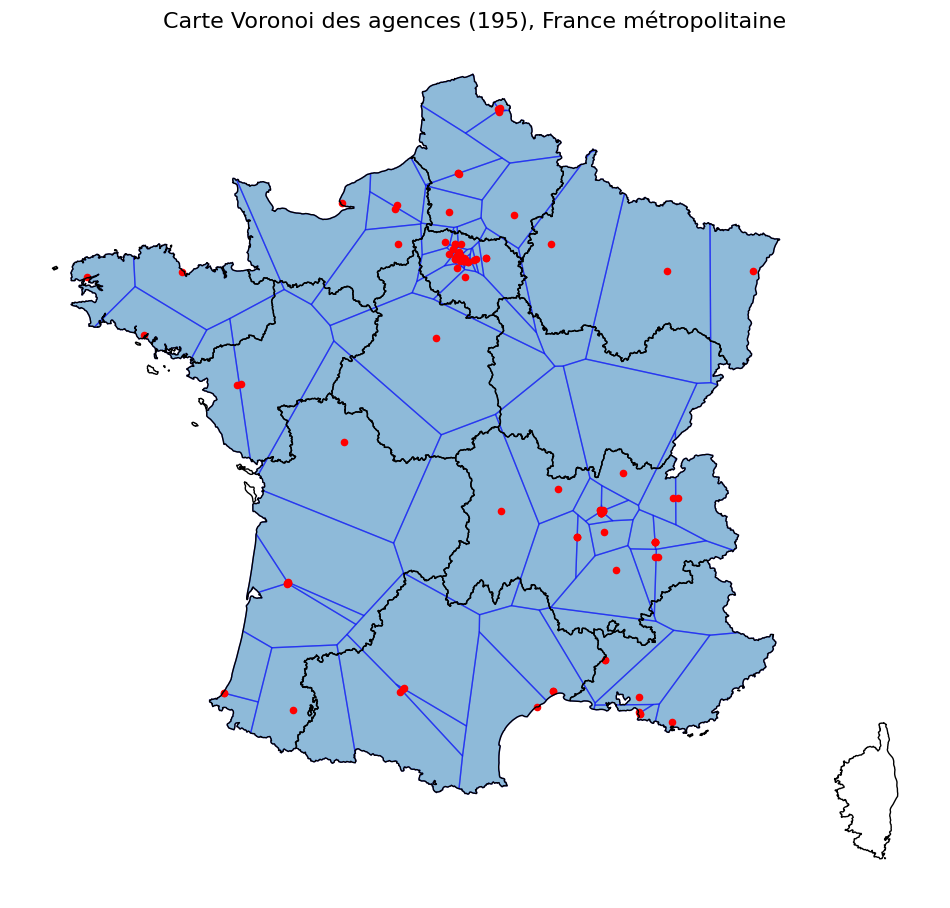

In [32]:
france_metropole = france_metropole.to_crs(epsg=2154)
gdf_proj = gdf_filtrée.to_crs(epsg=2154)

# Normalement on a 195 agences ici
print(f"Nombre d'agences utilisées pour Voronoi : {len(gdf_proj)}")

# On peut maintenant se lancer dans le calcul des régions de Voronoï

coords = np.array([(pt.x, pt.y) for pt in gdf_proj.geometry])
region_polys, region_pts = voronoi_regions_from_coords(coords, france_metropole.unary_union)
gdf_voronoi = gpd.GeoDataFrame({'geometry': list(region_polys.values())}, crs=gdf_proj.crs)

fig, ax = plt.subplots(figsize=(12, 12))
france_metropole.boundary.plot(ax=ax, edgecolor='black', linewidth=1)
gdf_voronoi.plot(ax=ax, alpha=0.5, edgecolor='blue')
gdf_proj.plot(ax=ax, color='red', markersize=20)  # tu peux ajuster ici la taille des points
plt.title("Carte Voronoi des agences (195), France métropolitaine", fontsize=16)
plt.axis('off')
plt.show()

In [33]:
total_polygons = 0
for geom in gdf_voronoi.geometry:
    if geom.type == 'Polygon':
        total_polygons += 1
    elif geom.type == 'MultiPolygon':
        total_polygons += len(geom.geoms)

print(f"Nombre total de polygones élémentaires (en éclatant les MultiPolygons) : {total_polygons}")

Nombre total de polygones élémentaires (en éclatant les MultiPolygons) : 117


C:\Users\quent\AppData\Local\Temp\ipykernel_10548\1889340944.py:3: ShapelyDeprecationWarning: The 'type' attribute is deprecated, and will be removed in the future. You can use the 'geom_type' attribute instead.
  if geom.type == 'Polygon':
C:\Users\quent\AppData\Local\Temp\ipykernel_10548\1889340944.py:5: ShapelyDeprecationWarning: The 'type' attribute is deprecated, and will be removed in the future. You can use the 'geom_type' attribute instead.
  elif geom.type == 'MultiPolygon':


In [34]:
# On crée un dataframe agences bien formaté...
gdf_agences = gpd.GeoDataFrame(
    localisations_agences,
    geometry=gpd.points_from_xy(localisations_agences.longitude, localisations_agences.latitude),
    crs="EPSG:4326"
)

# On reprojette tout en epsg 2154
gdf_agences = gdf_agences.to_crs(epsg=2154)
gdf_voronoi = gdf_voronoi.to_crs(epsg=2154)

# On copie la géométrie des polygones dans une colonne distincte avant le sjoin (spatoal join)
gdf_voronoi = gdf_voronoi.copy()
gdf_voronoi['polygone'] = gdf_voronoi.geometry

# Spatial join pour associer chaque point à un polygone
joined = gpd.sjoin(gdf_agences, gdf_voronoi, how='left', predicate='within')

# On ajoute la colonne 'polygone' au df localisations_agences de base
localisations_agences['polygone'] = joined['polygone'].values

print(localisations_agences.columns)

Index(['agence_id', 'agence_nom', 'agence_ville', 'agence_adresse',
       'agence_code_postal', 'adresse_complete', 'latitude', 'longitude',
       'polygone'],
      dtype='object')


**On relie chaque agence à une valeur pour la densité spatiale des transactions (par polygone Voronoï)**

In [35]:
# On met le polygone Voronoï en géométrie principale
gdf_agences_polygones = gpd.GeoDataFrame(
    localisations_agences.copy(),
    geometry=localisations_agences['polygone'],
    crs="EPSG:2154"
)

# On garde uniquement les colonnes utiles
gdf_agences_polygones = gdf_agences_polygones[['agence_id', 'agence_nom', 'polygone']].copy()

# On converti en gdf avec toujours le polygone en géométrie principale
gdf_agences_polygones = gpd.GeoDataFrame(gdf_agences_polygones, geometry='polygone', crs="EPSG:2154")

In [36]:
# On compte le nombre de transactions qu'il y a eu dans chaque agence
count_df = agence_transaction.groupby("agence_id").size().reset_index(name="nb_transactions")

agence_transaction = (
    agence_transaction
    .drop_duplicates(subset=["agence_id"])
    .merge(count_df, on="agence_id", how="left")
)

agence_transaction.head()

,agence_id,nb_transactions
0,18,5699
1,24,726
2,25,2610
3,86,219
4,59,103


In [37]:
# On ajoute la donnée du nombre de transactions qu'il y a eu par agence dans le geodataframe des polygones
gdf_agences_polygones = gdf_agences_polygones.merge(
    agence_transaction[['agence_id', 'nb_transactions']],
    on='agence_id',
    how='left'  # on garde toutes les agences, même celles sans transaction
)

# On complète par des 0 si jamais on a un polygone sans transaction, ce qui ne devrait pas arriver 
# normalement mais ne sait-on jamais
gdf_agences_polygones['nb_transactions'] = gdf_agences_polygones['nb_transactions'].fillna(0).astype(int)

print(gdf_agences_polygones.head())

gdf_agences_polygones.to_file("gdf_agences_polygones.geojson", driver="GeoJSON")

   agence_id                        agence_nom  \
0          8  CONSEILS & SERVICES  IMMOBILIERS   
1         16                            PERIAL   
2         19                       ALEX BOLTON   
3         23                             PRIMM   
4         25             ARTHUR LOYD IDF OUEST   

                                            polygone  nb_transactions  
0  POLYGON ((629657.96 6851437.473, 592285.118 68...                7  
1  POLYGON ((649274.001 6864785.507, 648208.7 686...                0  
2  POLYGON ((648914.185 6863378.023, 648467.427 6...            20577  
3  POLYGON ((648467.427 6863315.152, 648277.847 6...                6  
4  POLYGON ((644854.508 6869165.748, 647501.845 6...             2610  


In [38]:
print(gdf_agences_polygones)

     agence_id                        agence_nom  \
0            8  CONSEILS & SERVICES  IMMOBILIERS   
1           16                            PERIAL   
2           19                       ALEX BOLTON   
3           23                             PRIMM   
4           25             ARTHUR LOYD IDF OUEST   
..         ...                               ...   
101        441              EVOLIS LYON ACTIVITE   
102        449          EVOLIS ILE DE FRANCE EST   
103        460          EVOLIS ILE DE FRANCE SUD   
104        463       BMR Immobilier d’entreprise   
105        468                OCTOPUS IMMOBILIER   

                                              polygone  nb_transactions  
0    POLYGON ((629657.96 6851437.473, 592285.118 68...                7  
1    POLYGON ((649274.001 6864785.507, 648208.7 686...                0  
2    POLYGON ((648914.185 6863378.023, 648467.427 6...            20577  
3    POLYGON ((648467.427 6863315.152, 648277.847 6...                6  
4    

**On relie les lots aux négociateurs**

<Axes: >

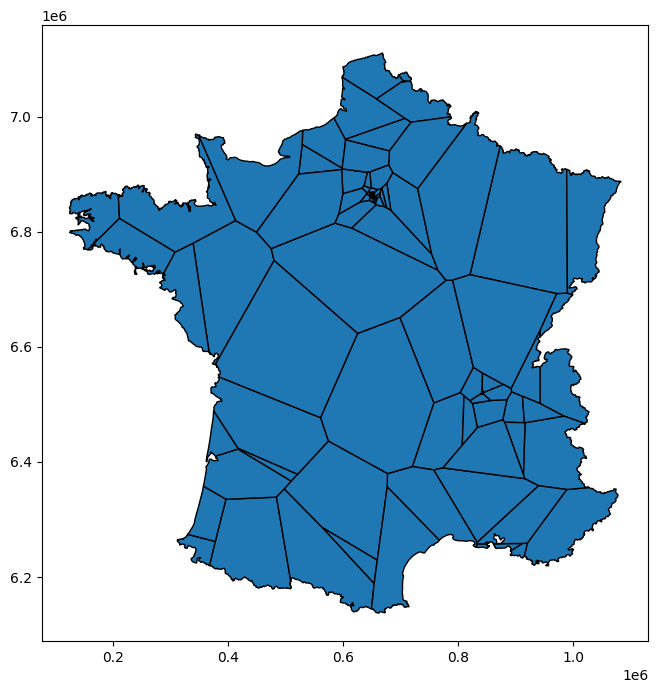

In [39]:
# On recharge les régions de Voronoi des agences

gdf_agences_polygones = gpd.read_file("gdf_agences_polygones.geojson")
gdf_agences_polygones.plot(edgecolor="black", figsize=(8, 8))

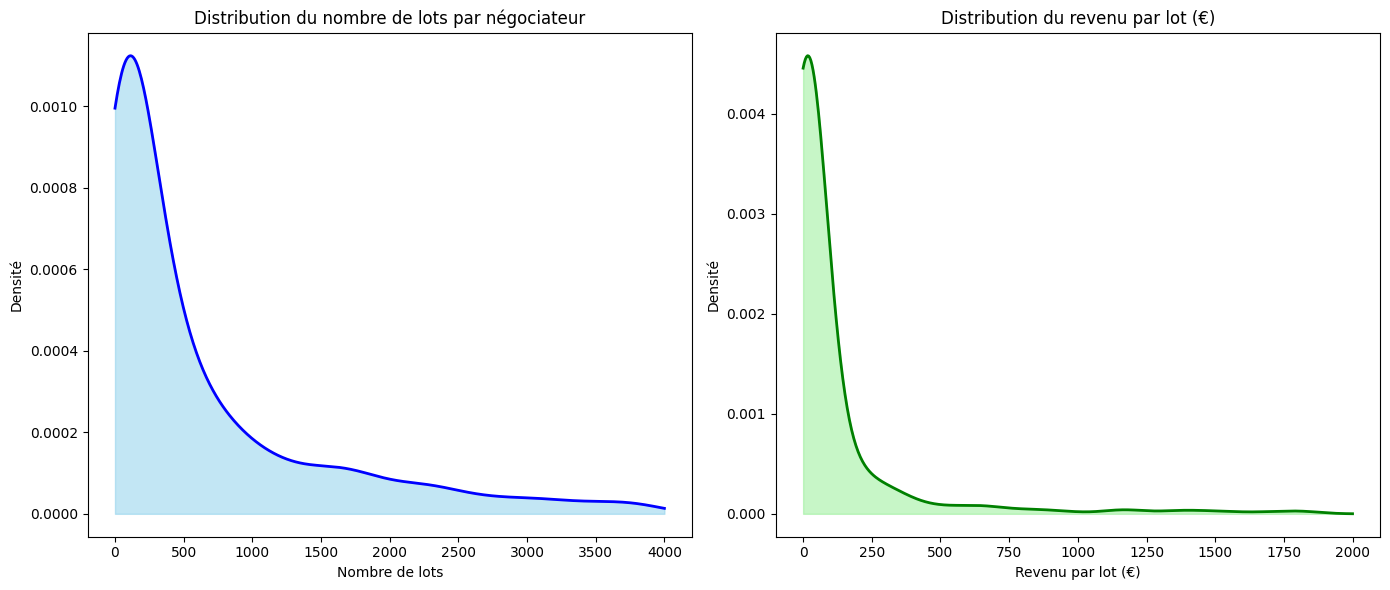

In [40]:
# On ouvre maintenant les distributions du nombre de lots gérés par négociateur et du revenu moyen par
# transaction par négociateur : 

with open("kde_nb_lots_negos.pkl", "rb") as f:
    kde_nb_lots_negos = pickle.load(f)

with open("kde_revenus_par_lot.pkl", "rb") as f:
    kde_revenus_par_lot = pickle.load(f)

# On définit les plages de valeurs pour chaque distribution
x_lots = np.linspace(0, 4000, 500) # pour le nombre de lots par négociateur
x_revenus = np.linspace(0, 2000, 500) # pour le revenu par lot (€)

y_lots = kde_nb_lots_negos.evaluate(x_lots)
y_revenus = kde_revenus_par_lot.evaluate(x_revenus)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Distribution du nombre de lots par négociateur
axes[0].plot(x_lots, y_lots, color='blue', lw=2)
axes[0].fill_between(x_lots, y_lots, color='skyblue', alpha=0.5)
axes[0].set_title("Distribution du nombre de lots par négociateur")
axes[0].set_xlabel("Nombre de lots")
axes[0].set_ylabel("Densité")

# Distribution du revenu par lot
axes[1].plot(x_revenus, y_revenus, color='green', lw=2)
axes[1].fill_between(x_revenus, y_revenus, color='lightgreen', alpha=0.5)
axes[1].set_title("Distribution du revenu par lot (€)")
axes[1].set_xlabel("Revenu par lot (€)")
axes[1].set_ylabel("Densité")

plt.tight_layout()
plt.show()

✅ CRS des lots : EPSG:2154
✅ CRS des agences : EPSG:2154
2,132,222 lots sur 2,133,958 ont été associés à une agence (99.92%).
Tableau provisoire (reste à ajouter le négociateur) :
    lot_id  agence_id
1   191627      146.0
6   191770      251.0
9   191777       65.0
12  191843      428.0
14  191845       25.0


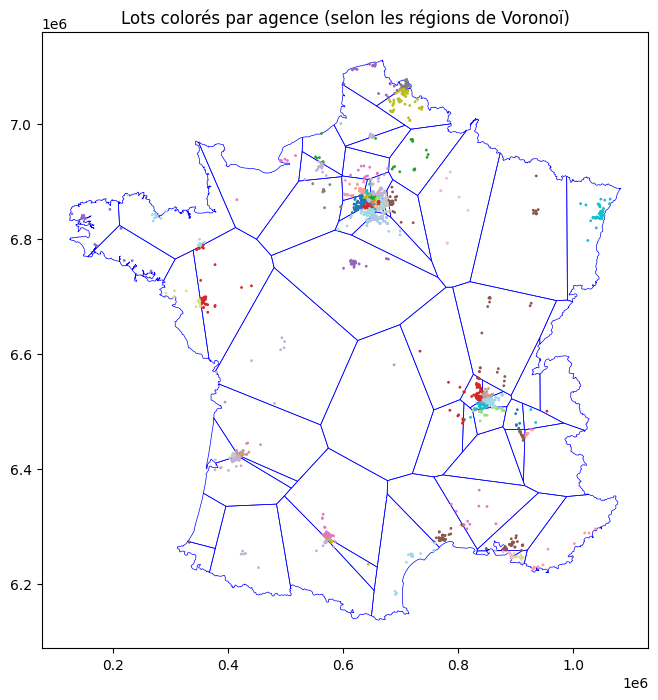

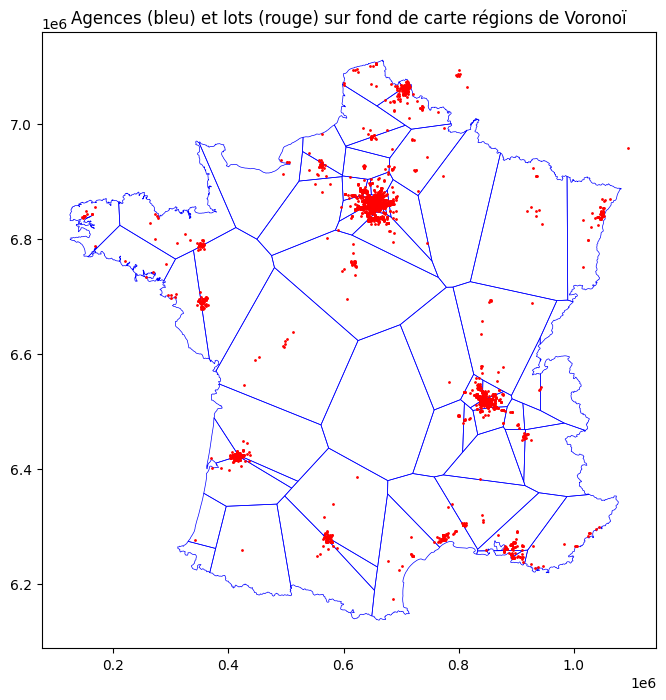

In [41]:
# On associe maintenant chaque lot à la région de Voronoï de son agence

# On fait une jointure spatiale pour ajouter au dataframe qui ne contient pour le moment que l'info lot / agence
# le polygone qui va avec

# Les coordonnées actuelles sont en degrés (WGS84)
gdf_lots = gpd.GeoDataFrame(
    lots_adresses.copy(),
    geometry=gpd.points_from_xy(lots_adresses["adr_plan_x"], lots_adresses["adr_plan_y"]),
    crs="EPSG:4326"  # système géographique
)

gdf_lots = gdf_lots.to_crs(epsg=2154)

# Normalement les deux doivent être dans le même système de projection
print("✅ CRS des lots :", gdf_lots.crs)
print("✅ CRS des agences :", gdf_agences_polygones.crs)

gdf_lots_agences = gpd.sjoin(
    gdf_lots,
    gdf_agences_polygones[['agence_id', 'geometry']],
    how="left",
    predicate="within"
)

gdf_lots_agences = gdf_lots_agences.drop_duplicates(subset='lot_id')

nb_associes = gdf_lots_agences['agence_id'].notna().sum()
total_lots = len(gdf_lots_agences)
print(f"{nb_associes:,} lots sur {total_lots:,} ont été associés à une agence ({nb_associes/total_lots:.2%}).")

lots_agences = gdf_lots_agences[['lot_id', 'agence_id']].copy()
lots_agences = lots_agences.drop_duplicates(subset='lot_id')

print("Tableau provisoire (reste à ajouter le négociateur) :")
print(lots_agences.head())

# On voit ce que ca donne visuellement
fig, ax = plt.subplots(figsize=(8, 8))
gdf_agences_polygones.plot(ax=ax, color='none', edgecolor='blue', linewidth=0.5)
gdf_lots_agences.sample(5000).plot(ax=ax, column='agence_id', markersize=1, cmap='tab20', legend=False)
plt.title("Lots colorés par agence (selon les régions de Voronoï)")
plt.show()

fig, ax = plt.subplots(figsize=(8, 8))
gdf_agences_polygones.plot(ax=ax, color='none', edgecolor='blue', linewidth=0.5)
gdf_lots.sample(5000).plot(ax=ax, color='red', markersize=1) # Affichage de 5000 points au hasard
plt.title("Agences (bleu) et lots (rouge) sur fond de carte régions de Voronoï")
plt.show()

In [42]:
# On ajoute la colonne negociateur_id
lots_agences = lots_agences.merge(
    lots_infos_basiques[['lot_id', 'negociateur_id']],
    on='lot_id',
    how='left'
)

lots_agences = lots_agences.merge(
    lots_adresses[['lot_id', 'adr_plan_x', 'adr_plan_y']],
    on='lot_id',
    how='left'
)

print("Nombre de lignes :", len(lots_agences))
print("Nombre de lots avec un négociateur associé :", lots_agences['negociateur_id'].notna().sum())
print(lots_agences.head())

Nombre de lignes : 2133958
Nombre de lots avec un négociateur associé : 2133958
   lot_id  agence_id  negociateur_id  adr_plan_x  adr_plan_y
0  191627      146.0               0    2.245568   48.833504
1  191770      251.0               0    2.323382   48.859384
2  191777       65.0             493    2.345677   48.868526
3  191843      428.0              34    2.283699   48.876213
4  191845       25.0              31    2.262101   48.884121


In [43]:
# On ajoute une colonne qui contient le nombre de lots que gère en ce moment le négociateur

negociateur_counts = (
    lots_agences.groupby("negociateur_id", as_index=False)
    .size()
    .rename(columns={"size": "negociateur_type"})
)

lots_agences = lots_agences.merge(
    negociateur_counts,
    on="negociateur_id",
    how="left"
)

print("Nombre de lignes :", len(lots_agences))
print(lots_agences.head())

Nombre de lignes : 2133958
   lot_id  agence_id  negociateur_id  adr_plan_x  adr_plan_y  negociateur_type
0  191627      146.0               0    2.245568   48.833504              3123
1  191770      251.0               0    2.323382   48.859384              3123
2  191777       65.0             493    2.345677   48.868526             27128
3  191843      428.0              34    2.283699   48.876213             15247
4  191845       25.0              31    2.262101   48.884121               808


In [44]:
lots_agences["negociateur_nb_lots"] = lots_agences["negociateur_type"]

In [45]:
# Calculer le nouvel identifiant à utiliser pour remplacer les NaN
nouvel_id = int(lots_agences['agence_id'].max()) + 1

# Remplacer les NaN dans la colonne 'agence_id'
lots_agences['agence_id'] = lots_agences['agence_id'].fillna(nouvel_id)

# Vérifier que ça a marché
print(lots_agences['agence_id'].isna().sum())  # devrait afficher 0

0


In [46]:
if lots_agences["agence_id"].isna().any():
    print("Il y a des agences manquantes !")
    print(lots_agences["agence_id"].unique().tolist())
else:
    print("Aucune agence manquante")

Aucune agence manquante


In [47]:
lots_agences.to_csv("lots_agences_negos.csv", index=False)

# C'EST LE TABLEAU DE DONNEES LE PLUS IMPORTANT

print(lots_agences.columns)

Index(['lot_id', 'agence_id', 'negociateur_id', 'adr_plan_x', 'adr_plan_y',
       'negociateur_type', 'negociateur_nb_lots'],
      dtype='object')


In [48]:
lots_agences = gpd.GeoDataFrame(
    lots_agences.copy(),
    geometry=gpd.points_from_xy(lots_agences["adr_plan_x"], lots_agences["adr_plan_y"]),
    crs="EPSG:4326"
)

lots_agences.to_crs(epsg=2154, inplace=True)

print(lots_agences.crs)

EPSG:2154


In [49]:
# Pour les offres
with open("processus_poisson_offres.pkl", "rb") as f:
    modele_poisson_offres = pickle.load(f)

lambda_offres = modele_poisson_offres['lambda']

print(lambda_offres)

# Pour les transactions
with open("poisson_transactions.pkl", "rb") as f:
    lambda_transactions = pickle.load(f)

print(lambda_transactions)

149.521257283148
27.49393190662326


In [50]:
# Création d’un vecteur de probabilité pour le nombre de lots par offre
nb_lots_offre['proba'] = nb_lots_offre['nb_occurrences'] / nb_lots_offre['nb_occurrences'].sum()

In [51]:
gdf_agences_polygones = gdf_agences_polygones.to_crs("EPSG:2154")

In [52]:
kde_france_gdf = kde_france_gdf.to_crs(epsg=2154)

print(kde_france_gdf.crs)

EPSG:2154


In [53]:
# Important pour avoir de la variabilité au niveau de l'activité des négociateurs : on bruite leur type
# Car si aujourd'hui un négociateur gère x lots, cela ne signifie pas qu'il est dans son activité habituelle
# Il est peut-être dans une période de faible activité, ou dans une période de forte activité, donc on 
# écarte son type de son nombre de lots gérés d'une N(0,sigma=15% de son nombre de lots actuel)

# On extrait 1 ligne par négociateur
neg_data = (
    lots_agences[["negociateur_id", "negociateur_nb_lots"]]
    .drop_duplicates("negociateur_id")
    .set_index("negociateur_id")
)

# Conversion sécurisée
neg_data["negociateur_nb_lots"] = pd.to_numeric(
    neg_data["negociateur_nb_lots"], errors="coerce"
).fillna(0)

# Bruit gaussien (sigma = 20%), pour que le systéme ne suraccumule pas pour basculer brutalement au bout
# d'un temps certain. On étale les données, on déséquilibre le modele pour que la stochastique fasse son
# travail au fur et à mesure sans basculement brutal.
sigma_ratio = 0.2
bruit = np.random.normal(
    loc=0,
    scale=sigma_ratio * neg_data["negociateur_nb_lots"].values
)

# Type bruité
type_bruite = neg_data["negociateur_nb_lots"] + bruit

# Si type_bruite est NaN, on remet la valeur d'origine
type_bruite = np.where(
    np.isnan(type_bruite),
    neg_data["negociateur_nb_lots"],  # valeur originale
    type_bruite
)

# Conversion en entier + clip
neg_data["negociateur_type_bruite"] = np.clip(np.round(type_bruite).astype(int), a_min=1, a_max=None)

# Réinjection dans lots_agences
lots_agences = lots_agences.merge(
    neg_data[["negociateur_type_bruite"]],
    left_on="negociateur_id",
    right_index=True,
    how="left"
)

# On remplace l’ancienne colonne "negociateur_type"
lots_agences["negociateur_type"] = lots_agences["negociateur_type_bruite"]

# Nettoyage
lots_agences = lots_agences.drop(columns=["negociateur_type_bruite"])

print("Bruitage des negociateur_type terminé !")
print(lots_agences.head())

Bruitage des negociateur_type terminé !
   lot_id  agence_id  negociateur_id  adr_plan_x  adr_plan_y  \
0  191627      146.0               0    2.245568   48.833504   
1  191770      251.0               0    2.323382   48.859384   
2  191777       65.0             493    2.345677   48.868526   
3  191843      428.0              34    2.283699   48.876213   
4  191845       25.0              31    2.262101   48.884121   

   negociateur_type  negociateur_nb_lots                        geometry  
0              3529                 3123  POINT (644620.777 6859536.713)  
1              3529                 3123   POINT (650357.295 6862362.57)  
2             31894                27128  POINT (652001.433 6863365.279)  
3             10273                15247  POINT (647462.812 6864259.526)  
4               674                  808  POINT (645886.956 6865153.316)  


In [54]:
# on réduit maintenant la mémoire ram demandée par lots_agences

# Trouver le max existant et convertir en int
max_nego_id = int(lots_agences["negociateur_id"].max())

# Remplacer les NaN par des identifiants uniques à la suite
nan_mask = lots_agences["negociateur_id"].isna()
lots_agences.loc[nan_mask, "negociateur_id"] = range(
    max_nego_id + 1,
    max_nego_id + 1 + nan_mask.sum()
)

# Conversion en int32
lots_agences["negociateur_id"] = lots_agences["negociateur_id"].astype("int32")

lots_agences["negociateur_id"] = lots_agences["negociateur_id"].astype("int32")
lots_agences["agence_id"] = lots_agences["agence_id"].astype("int32")
lots_agences["lot_id"] = lots_agences["lot_id"].astype("int32")
lots_agences["negociateur_type"] = lots_agences["negociateur_type"].astype("int32")
# Remplacer les NaN par 0 (ou une autre valeur cohérente selon ton métier)

lots_agences["negociateur_nb_lots"] = lots_agences["negociateur_nb_lots"].fillna(0)

lots_agences["negociateur_nb_lots"] = lots_agences["negociateur_nb_lots"].astype("int32")
lots_agences["adr_plan_x"] = lots_agences["adr_plan_x"].astype("float32")
lots_agences["adr_plan_y"] = lots_agences["adr_plan_y"].astype("float32")

**DEFINITION DES FONCTIONS QUI GENERERONT LES DONNEES**

In [55]:
def type_identifiant_nouveau_nego(lots_agences_copie) :
    type_nouveau_nego = np.floor(kde_nb_lots_negos.resample(1)[0][0]) + 1
    while type_nouveau_nego <= 0 :
        type_nouveau_nego = np.floor(kde_nb_lots_negos.resample(1)[0][0]) + 1
    identifiant_nouveau_nego = max(lots_agences_copie["negociateur_id"]) + 1
    return (type_nouveau_nego, identifiant_nouveau_nego)

print(type_identifiant_nouveau_nego(lots_agences))

(102.0, 5871)


In [56]:
lambda_offres = modele_poisson_offres["lambda"]  # déjà calculé plus haut
nb_jours = 365
start_date = pd.Timestamp.today().normalize()  # date du jour à minuit

def dates_nouvelles_offres():
    dates = []
    current_date = start_date

    while current_date < start_date + pd.Timedelta(days=nb_jours):
        # Tirage aléatoire du temps entre deux offres (processus de Poisson)
        delta = np.random.exponential(scale=1 / lambda_offres)
        current_date += pd.Timedelta(days=delta)
        if current_date < start_date + pd.Timedelta(days=nb_jours):
            dates.append(current_date)

    return pd.Series(dates)

print(dates_nouvelles_offres())

0       2026-01-13 00:50:46.334401904
1       2026-01-13 01:08:04.995398762
2       2026-01-13 01:14:30.889316574
3       2026-01-13 01:15:41.502801254
4       2026-01-13 01:29:46.230264682
                     ...             
54549   2027-01-12 22:42:43.467801831
54550   2027-01-12 22:54:28.671580211
54551   2027-01-12 23:06:46.625027354
54552   2027-01-12 23:21:48.796595034
54553   2027-01-12 23:48:22.222470188
Length: 54554, dtype: datetime64[ns]


In [57]:
def dates_nouvelles_transactions():
    dates = []
    current_date = start_date

    while current_date < start_date + pd.Timedelta(days=nb_jours):
        # Tirage aléatoire du temps entre deux transactions (processus de Poisson)
        delta = np.random.exponential(scale=1 / lambda_transactions)
        current_date += pd.Timedelta(days=delta)
        if current_date < start_date + pd.Timedelta(days=nb_jours):
            dates.append(current_date)

    return pd.Series(dates)

print(dates_nouvelles_transactions())

0      2026-01-13 02:19:23.856827714
1      2026-01-13 02:44:41.365811635
2      2026-01-13 02:52:10.965134793
3      2026-01-13 03:09:54.133459884
4      2026-01-13 03:19:39.101917244
                    ...             
9883   2027-01-12 19:27:02.300993143
9884   2027-01-12 20:57:22.566372988
9885   2027-01-12 21:13:49.195417840
9886   2027-01-12 21:42:11.644288975
9887   2027-01-12 23:45:53.964106237
Length: 9888, dtype: datetime64[ns]


In [58]:
def nb_lots_nouvelle_offre(lots_agences_copie) :
    
    nombre_de_lots = np.random.choice(
    nb_lots_offre['nb_occurrences'],
    size=1,
    replace=True,
    p=nb_lots_offre['proba']
    )[0]

    identifiants_nouveaux_lots = []

    for i in range(nombre_de_lots) :
        identifiants_nouveaux_lots.append(lots_agences_copie['lot_id'].max() + i + 1)

    return identifiants_nouveaux_lots

print(nb_lots_nouvelle_offre(lots_agences))

[5100924]


In [59]:
def nb_lots_nouvelle_offre_vectorise(n):
    return np.random.choice(
        nb_lots_offre["nb_occurrences"],
        size=n,
        replace=True,
        p=nb_lots_offre["proba"]
    )

print(nb_lots_nouvelle_offre_vectorise(10000))

[ 2  4  2 ... 57  8  3]


In [60]:
def nouvelle_offre_lieu() :
    # Tirer une cellule selon la densité
    indices = np.random.choice(kde_france_gdf.index, p=kde_france_gdf['density'])
    
    # Coordonnées du centre de la cellule
    x_centre = float(kde_france_gdf.loc[indices, 'x'])
    y_centre = float(kde_france_gdf.loc[indices, 'y'])
    
    # Ajouter un petit bruit pour disperser à l'intérieur de la cellule (±500 m)
    x_point = x_centre + np.random.uniform(-500, 500)
    y_point = y_centre + np.random.uniform(-500, 500)
    
    return x_point, y_point

print(nouvelle_offre_lieu())

(257528.69255846657, 6249383.446014448)


In [61]:
# On récupère les colonnes sous forme de vecteurs NumPy
density = kde_france_gdf["density"].values
xs = kde_france_gdf["x"].values
ys = kde_france_gdf["y"].values

# Pré-calcul de la CDF (cumul des densités normalisé)
cdf = np.cumsum(density)
cdf /= cdf[-1]  # normalisation (assure que max = 1)

def nouvelles_offres_lieux_vectorise(n):
    # Tirage uniforme
    u = np.random.random(size=n)

    # Conversion en indices selon la densité via la CDF
    idx = np.searchsorted(cdf, u)

    # Récupération vectorisée des centres
    x_centres = xs[idx]
    y_centres = ys[idx]

    # Bruit ±500 m vectorisé
    bruit = np.random.uniform(-500, 500, size=(n, 2))

    # Résultat final
    return np.column_stack((x_centres, y_centres)) + bruit

In [62]:
print(gdf_agences_polygones.crs)
print(kde_france_gdf.crs)

# ATTENTION, SEUL L'EPSG 3857 (WEB MERCATOR) FONCTIONNE QUOI QU'IL ARRIVE !!!
# ON PEUT TOUJOURS TOUT PROJETER EN LAMBERT 93 OU EN WGS 84, CA NE FONCTIONNERA PAS
# Le résultat sera étrange en Lambert 93 par exemple (malgré reprojection de tous les dataframes en epsg2154)
# On aura l'agglomération parisienne qui se retrouvera vers Biaritz, et tous les points seront beaucoup trop 
# écartés les uns des autres, avec au lieu de 400 kilomètres à vol d'oiseau entre Paris et Lyon par exemple, 
# on se retrouve avec l'équivalent de la distance Paris - Marseille... 
# Pourquoi ces bizarreries ? Aucune idée, après deux jours complet à projeter des coordonnées dans tous les
# sens, je n'ai trouvé aucune explication.

gdf_agences_polygones = gdf_agences_polygones.to_crs(epsg=3857)
kde_france_gdf = kde_france_gdf.to_crs(epsg=3857)

print(gdf_agences_polygones.crs)
print(kde_france_gdf.crs)

EPSG:2154
EPSG:2154
EPSG:3857
EPSG:3857


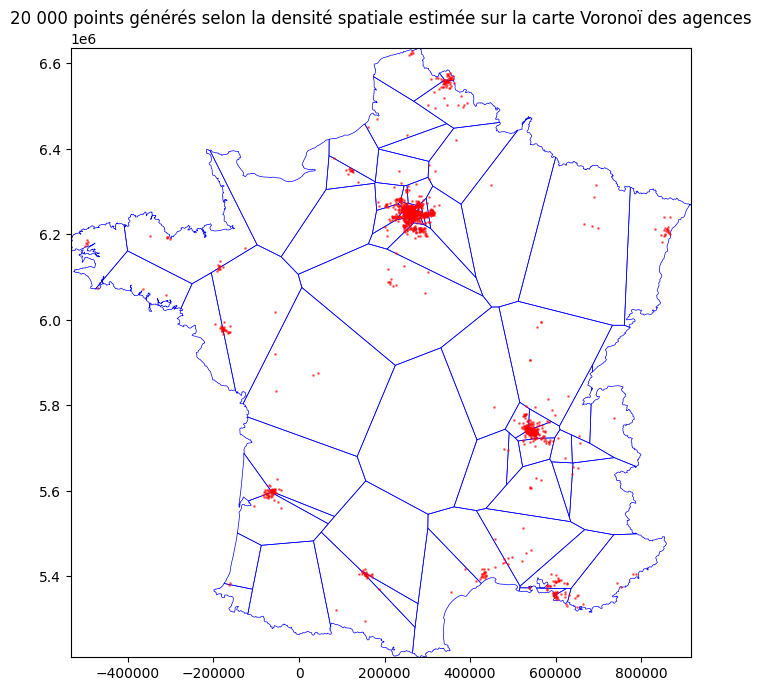

Bornes des polygones agence : [-533592.50891973 5211089.89996111  916203.78802854 6636971.04987137]
Exemple de point : 276791.88491349673 6266101.475599437


In [63]:
# Cellule d'exemple, pour voir si la fonction de génération de lieux aléatoires fonctionne bien

points = [Point(*nouvelle_offre_lieu()) for _ in range(2000)]
gdf_points = gpd.GeoDataFrame(geometry=points, crs="EPSG:3857")

if gdf_points.crs != gdf_agences_polygones.crs:
    gdf_points = gdf_points.to_crs(gdf_agences_polygones.crs)
    print("🔄 Points reprojetés pour correspondre au CRS des agences.")

fig, ax = plt.subplots(figsize=(8, 8))

gdf_agences_polygones.plot(ax=ax, color='none', edgecolor='blue', linewidth=0.5)
gdf_points.plot(ax=ax, color='red', markersize=1, alpha=0.5)

xmin, ymin, xmax, ymax = gdf_agences_polygones.total_bounds
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_aspect('equal')

plt.title("20 000 points générés selon la densité spatiale estimée sur la carte Voronoï des agences")
plt.show()

print("Bornes des polygones agence :", gdf_agences_polygones.total_bounds)
print("Exemple de point :", gdf_points.geometry.iloc[0].x, gdf_points.geometry.iloc[0].y)

In [64]:
def attribution_lot_agence_point(x, y) :
    # Crée un GeoDataFrame d'un seul point
    gdf_point = gpd.GeoDataFrame(
        geometry=[Point(x, y)],
        crs="EPSG:3857"
    )
    
    # Jointure spatiale
    result = gpd.sjoin(
        gdf_point,
        gdf_agences_polygones[['agence_id', 'geometry']],
        how='left',
        predicate='within'
    )
    
    agence_id = result.iloc[0]['agence_id'] if pd.notna(result.iloc[0]['agence_id']) else None
    
    return [x, y, agence_id]

x, y = nouvelle_offre_lieu()
x, y, agence_id = attribution_lot_agence_point(x, y)
print(x, y, agence_id)

251718.1754373641 6259194.470004169 215


In [65]:
def attribution_lot_agence_vectorise(xs, ys):
    points = gpd.GeoSeries(gpd.points_from_xy(xs, ys), crs="EPSG:3857")
    str_tree = gdf_agences_polygones.sindex   # spatial index GeoPandas

    results = []

    for p in points:
        # indices candidats
        matches = str_tree.query(p)

        if len(matches) == 0:
            results.append(None)
            continue

        agence_id = None

        for idx in matches:
            poly_geom = gdf_agences_polygones.iloc[idx].geometry
            if poly_geom.contains(p):
                agence_id = gdf_agences_polygones.iloc[idx]["agence_id"]
                break

        results.append(agence_id)

    return results

In [66]:
def nouvelle_transaction(lots_agences_copie) :
    negociateur_sans_lot = True

    while negociateur_sans_lot == True :
        # On trouve les revenus que va générer cette transaction
        revenus = np.floor(kde_revenus_par_lot.resample(1)[0][0]) + 1
        while revenus <= 0 :
            revenus = np.floor(kde_revenus_par_lot.resample(1)[0][0]) + 1

        # On trouve aussi l'agence qui signera pour cette transaction
        agences = gdf_agences_polygones["agence_id"].values
        poids = gdf_agences_polygones["nb_transactions"].values

        # On normalise pour obtenir une distribution de probabilité
        poids = poids / poids.sum()

        # On tire un numéro d'agence selon cette loi
        agence_de_la_transac = np.random.choice(agences, p=poids)

        # On trouve aussi le négociateur qui a signé, pareil, on attribue la probabilité selon le nombre
        # de lots gérés
        negos_de_l_agence = lots_agences_copie.loc[
            lots_agences_copie["agence_id"] == agence_de_la_transac,
            ["negociateur_id", "negociateur_type"]
        ].drop_duplicates()
        poids = negos_de_l_agence["negociateur_type"].values
        poids = poids / poids.sum()

        try :
            negociateur = np.random.choice(negos_de_l_agence["negociateur_id"].values, p=poids)

            # Tirage du lot seulement si le négociateur a au moins un lot
            lots_du_nego = lots_agences_copie.loc[
                lots_agences_copie["negociateur_id"] == negociateur,
                "lot_id"
            ].drop_duplicates()

            lot_transactionne = np.random.choice(lots_du_nego.values)

            negociateur_sans_lot = False

        except Exception as e :
            # Si erreur (pas de lot), on continue la boucle pour tirer un nouveau négociateur
            continue

    return [revenus, agence_de_la_transac, negociateur, lot_transactionne]

print(nouvelle_transaction(lots_agences))

[43.0, 152, 2849, 1307083]


In [67]:
def nouvelle_transaction_fast_vector(
    lots_agences_copie,
    negos_by_agence,
    lots_by_neg,
    agence_ids,
    agence_weights,
    kde_revenus_par_lot,
    nb_transacs
) :

    # 1. Tirage des revenus pour toutes les transactions
    revenus_raw = kde_revenus_par_lot.resample(nb_transacs)[0]
    revenus = np.floor(revenus_raw).astype(int) + 1
    revenus[revenus <= 0] = 1
    
    # 2. Tirage des agences pour toutes les transactions
    agences = np.random.choice(agence_ids, size=nb_transacs, p=agence_weights)
    
    # 3. Tirage des négociateurs et lots
    negociateurs = np.empty(nb_transacs, dtype=object)
    lots_ids = np.empty(nb_transacs, dtype=object)
    
    for ag in np.unique(agences):
        indices = np.where(agences == ag)[0]
        negos = negos_by_agence[ag]
        nego_ids = np.array(negos[:,0], dtype=object)
        nego_weights = np.array(negos[:,1], dtype=float)
        nego_weights = nego_weights / nego_weights.sum()
        
        # Tirage négociateurs pour cette agence
        tirages_nego = np.random.choice(nego_ids, size=len(indices), p=nego_weights)
        negociateurs[indices] = tirages_nego
        
        # Tirage lots disponibles
        for idx, neg in zip(indices, tirages_nego):
            lots_dispo = lots_by_neg.get(neg, None)
            if lots_dispo is None or len(lots_dispo) == 0:
                # On prend un lot aléatoire de la même agence si vide (rare)
                lots_dispo = lots_agences_copie[lots_agences_copie["agence_id"] == ag]["lot_id"].values
            lots_ids[idx] = np.random.choice(lots_dispo)
    
    return revenus, agences, negociateurs, lots_ids

In [68]:
# On ajoute les dates de mise en ligne des lots, pour retirer les lots les plus vieux quand on devra retirer 
# des lots du marché
# En pratique ça ne se passe pas vraiment comme ça, mais c'est une heuristique simple

print(lots_agences.columns)

conn_str = (
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=172.16.11.34;"
    "DATABASE=LogiProDev;"
    "UID=quentin;"
    "PWD={Barbidur1;SQL}"
)

conn = pyodbc.connect(conn_str)
cursor = conn.cursor()

requete_tj_offre_lot = """ 
SELECT lot_id, ol_date_creation FROM tj_offre_lot
"""

dates_ol = pd.read_sql_query(requete_tj_offre_lot, conn)

conn.commit()
cursor.close()
conn.close()

lots_agences = lots_agences.merge(
    dates_ol[["lot_id", "ol_date_creation"]],
    on="lot_id",
    how="left"
)

lots_agences = lots_agences.rename(columns={"ol_date_creation": "date_mise_en_ligne"})

print(lots_agences.columns)

lots_agences["date_mise_en_ligne"] = pd.to_datetime(lots_agences["date_mise_en_ligne"])

lots_agences = lots_agences.sort_values(by="date_mise_en_ligne", ascending=True)

lots_agences = lots_agences.reset_index(drop=True)

Index(['lot_id', 'agence_id', 'negociateur_id', 'adr_plan_x', 'adr_plan_y',
       'negociateur_type', 'negociateur_nb_lots', 'geometry'],
      dtype='object')


C:\Users\quent\AppData\Local\Temp\ipykernel_10548\2047612412.py:22: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  dates_ol = pd.read_sql_query(requete_tj_offre_lot, conn)


Index(['lot_id', 'agence_id', 'negociateur_id', 'adr_plan_x', 'adr_plan_y',
       'negociateur_type', 'negociateur_nb_lots', 'geometry',
       'date_mise_en_ligne'],
      dtype='object')


In [69]:
def attribuer_negociateurs(lots_df):
    
    # On parcourt les lots
    for idx, lot in lots_df.iterrows():
        # Filtrer les négociateurs de la même agence
        candidats = lots_df[(lots_df['agence_id'] == lot['agence_id']) & (lots_df['negociateur_id'].notna())].copy()
        
        # S'il n'y a pas de négociateur existant pour cette agence, ignorer
        if candidats.empty:
            lots_df.at[idx, 'negociateur_id'] = None
            continue
        
        # Calculer la "distance" à la capacité
        candidats['distance'] = (candidats['negociateur_type'] - candidats['negociateur_nb_lots']).abs()
        
        # Choisir celui qui a le plus grand écart
        neg_id = candidats.sort_values('distance', ascending=False).iloc[0]['negociateur_id']
        
        # Attribuer le lot
        lots_df.at[idx, 'negociateur_id'] = neg_id
        
        # Incrémenter le compteur pour ce négociateur
        lots_df.loc[lots_df['negociateur_id'] == neg_id, 'negociateur_nb_lots'] += 1
    
    return lots_df

**Attention, pour que ça fonctionne, TOUT DOIT ÊTRE FAIT EN WEB MERCATOR !!**

**BOUCLE FINALE POUR LA SIMULATION DE MONTE CARLO**

In [70]:
nb_iterations = 1
start_date = pd.Timestamp.today().normalize()

In [71]:
# On garde les données de ce qui se sera passé dans chacune des simulations

nombre_de_nouvelles_offres_par_iteration = []

transactions = pd.DataFrame(columns=[
    "numero_iteration",
    "revenus",
    "agence_id",
    "negociateur_id",
    "lot_id"
])

rh = pd.DataFrame(columns=[
    "numero_iteration",
    "negociateur_id",
    "agence_id",
    "negociateur_type", 
    "recrutement_ou_licenciement"
])

Sans parallélisation : 

Niveau temps d'exécution, compter cinquante minutes pour faire une année quand la granularité est la semaine. 
Ca fait long, pour une simulation de Monte Carlo à 300 itérations, il faudra compter une dizaine de jours...

In [72]:
def afficher_dataframes():
    dfs = {name: obj for name, obj in globals().items()
           if isinstance(obj, (pd.DataFrame, gpd.GeoDataFrame))}
    
    print("📌 DataFrames encore présents dans la mémoire globale :\n")
    for name, df in dfs.items():
        mem = df.memory_usage(deep=True).sum() / (1024**2)
        print(f"- {name}  ({mem:.2f} MB, shape={df.shape})")

print(afficher_dataframes())

📌 DataFrames encore présents dans la mémoire globale :

- lots_infos_basiques  (156.12 MB, shape=(2242533, 9))
- lots_loyers  (14.72 MB, shape=(617500, 4))
- lots_codes_insee  (1478.04 MB, shape=(7498773, 5))
- lots_adresses  (704.98 MB, shape=(2133958, 10))
- demandes  (13.51 MB, shape=(141491, 9))
- gestion_de_lots_negociateurs  (0.15 MB, shape=(1065, 5))
- transactions_revenus_negociateurs  (0.11 MB, shape=(655, 8))
- negociateurs_mandats  (5.98 MB, shape=(33445, 10))
- agences_negociateurs  (1.65 MB, shape=(4145, 10))
- offres_dates_creation  (1.65 MB, shape=(216205, 1))
- dates_transac  (0.60 MB, shape=(39434, 1))
- agence_transaction  (0.00 MB, shape=(171, 2))
- nb_lots_negos  (0.02 MB, shape=(1618, 2))
- nb_lots_offre  (15.55 MB, shape=(679452, 3))
- __  (0.00 MB, shape=(5, 2))
- localisations_agences  (0.04 MB, shape=(106, 9))
- gdf_agences  (0.04 MB, shape=(106, 9))
- gdf_offres  (721.26 MB, shape=(2133946, 11))
- lots_actifs  (19.25 MB, shape=(2242533, 2))
- gdf_regions  (0.0

In [73]:
# pour faire de la place dans la mémoire avant d'exécuter le passage lourd, on supprime tout ce dont
# on n'a plus besoin

def meminfo(message=""):
    process = psutil.Process(os.getpid())
    mem_used_mb = process.memory_info().rss / (1024 ** 2)  # mémoire utilisée par ton script
    mem_sys = psutil.virtual_memory()

    print(f"\n---- {message} ----")
    print(f"Mémoire utilisée par le processus : {mem_used_mb:,.2f} MB")
    print(f"Mémoire RAM totale : {mem_sys.total / (1024**3):.2f} GB")
    print(f"RAM utilisée totale : {mem_sys.used / (1024**3):.2f} GB")
    print(f"RAM disponible : {mem_sys.available / (1024**3):.2f} GB")
    print("------------------------------\n")

meminfo("AVANT nettoyage")

del lots_infos_basiques
del lots_loyers
del kde_france
del lots_actifs
del density_df
del gdf_lots
del gdf_lots_agences
del france_metropole
del france_metropole_4326
del france
del count_df
del df_lots_par_region
del agence_transaction
del dates_transac
del joined
del gdf_proj
del density_all
del gdf_filtrée
del nb_lots_negos
del gdf_agences
del gdf_agences_metropole
del localisations_agences
del lots_codes_insee
del gdf_voronoi
del df_region
del gdf_regions
del lots_adresses
del gdf_offres
del demandes
del gestion_de_lots_negociateurs
del negociateurs_mandats
del agences_negociateurs
del transactions_revenus_negociateurs
del offres_dates_creation

gc.collect()

meminfo("APRÈS nettoyage")


---- AVANT nettoyage ----
Mémoire utilisée par le processus : 6,506.89 MB
Mémoire RAM totale : 15.80 GB
RAM utilisée totale : 13.56 GB
RAM disponible : 2.24 GB
------------------------------


---- APRÈS nettoyage ----
Mémoire utilisée par le processus : 4,398.63 MB
Mémoire RAM totale : 15.80 GB
RAM utilisée totale : 11.56 GB
RAM disponible : 4.24 GB
------------------------------



In [74]:
lots_agences.memory_usage(deep=True).sum() / (1024 ** 2)   # en MB

100.32837677001953

In [75]:
for i in range(nb_iterations) : 

    heure_de_lancement = time.time()

    i += 1
    print(f"Début de l'itération n°{i}, {time.time() - heure_de_lancement:.2f}")

    # A chaque nouvelle itération, on repart de l'état réel d'aujourd'hui
    lots_agences_copie = lots_agences.copy()

    # On génère les dates des nouvelles offres
    nouvelles_offres = dates_nouvelles_offres()
    print(f"Les dates des nouvelles offres ont été générées avec succès, {time.time() - heure_de_lancement:.2f}")
    nouvelles_offres = pd.DataFrame({"date_offre": nouvelles_offres})

    nombre_de_nouvelles_offres_par_iteration.append(len(nouvelles_offres))

    # On attribue un nombre de lots aléatoire pour chacune de ces offres
    nouvelles_offres["nb_lots"] = nb_lots_nouvelle_offre_vectorise(len(nouvelles_offres))
    print(f"Le nombre de lots de chaque offre a été défini, {time.time() - heure_de_lancement:.2f}")
    
    # On attribue maintenant des coordonnées selon la densité spatiale pour chacune de ces offres
    # nouvelles_offres[["x", "y"]] = nouvelles_offres["date_offre"].apply(lambda _: pd.Series(nouvelle_offre_lieu()))
    coords = nouvelles_offres_lieux_vectorise(len(nouvelles_offres))
    nouvelles_offres["x"] = coords[:, 0]
    nouvelles_offres["y"] = coords[:, 1]
    print(f"Coordonnées spatiales des nouvelles offres attribuées, {time.time() - heure_de_lancement:.2f}")

    # On attribue maintenant une agence à chaque offre selon les polygones Voronoï
    nouvelles_offres["agence_id"] = attribution_lot_agence_vectorise(nouvelles_offres["x"].values, nouvelles_offres["y"].values)
    print(f"Agences attribuées, {time.time() - heure_de_lancement:.2f}")

    dates_transacs = dates_nouvelles_transactions()
    print(f"Dates des transactions définies, {time.time() - heure_de_lancement:.2f}")

    max_lot_id = lots_agences_copie["lot_id"].max()
    prochain_lot_id = max_lot_id + 1
    nouveaux_lots_list = []

    # On parcourt chaque offre
    for _, offre in nouvelles_offres.iterrows():
        nb_lots = len(offre["nb_lots"]) if isinstance(offre["nb_lots"], list) else offre["nb_lots"]
        
        # On ajoute un identifiant aux nouveaux lots
        for _ in range(nb_lots) :

            # On ajoute les infos des nouveaux lots dans le format lots_agences_copie à la liste des nouveaux lots
            nouveaux_lots_list.append({
                "lot_id": prochain_lot_id,
                "agence_id": offre["agence_id"],
                "negociateur_id": None,
                "adr_plan_x": offre["x"],
                "adr_plan_y": offre["y"],
                "negociateur_type": None,
                "negociateur_nb_lots" : None,
                "geometry" : None,
                "date_mise_en_ligne" : offre["date_offre"]
            })
            prochain_lot_id += 1

    # Dataframe des nouveaux lots, même structure que le df lots_agences_copie
    nouveaux_lots = pd.DataFrame(nouveaux_lots_list)
    print(f"On a le dataframe des nouveaux lots, {time.time() - heure_de_lancement:.2f}")
    # Attention, on va ajouter toutes ses lignes à la fin de lots_agences_copie, mais pour l'instant certaines
    # colonnes sont encore vides, à savoir : 
    # negociateur_id, negociateur_type, negociateur_nb_lots, geometry

    # On commence par ajouter la géométrie de la zone dans laquelle va se trouver le lot
    agence_to_geometry = lots_agences_copie.drop_duplicates(subset="agence_id").set_index("agence_id")["geometry"]
    nouveaux_lots["geometry"] = nouveaux_lots["agence_id"].map(agence_to_geometry)

    print(f"Cette année, {len(nouveaux_lots)} nouveaux lots ! {time.time() - heure_de_lancement:.2f}")

    # On boucle sur l'annee
    for semaine in range(52) :
        semaine += 1
        print(f"Semaine n°{semaine}, {time.time() - heure_de_lancement:.2f}")

        # Définition de la semaine courante et de la semaine suivante
        date_debut = start_date + pd.Timedelta(weeks=semaine)
        date_fin   = date_debut + pd.Timedelta(weeks=1)
        
        # Sélection des offres de la semaine
        offres_de_la_semaine = nouvelles_offres[(nouvelles_offres["date_offre"] >= date_debut) & (nouvelles_offres["date_offre"] < date_fin)]
        lots_de_la_semaine = nouveaux_lots[(nouveaux_lots["date_mise_en_ligne"] >= date_debut) & (nouveaux_lots["date_mise_en_ligne"] < date_fin)]

        print(f"Cette semaine, {len(offres_de_la_semaine)} nouvelles offres, dont {len(lots_de_la_semaine)} nouveaux lots, {time.time() - heure_de_lancement:.2f}")

        nego_type_dict = lots_agences_copie.drop_duplicates("negociateur_id").set_index("negociateur_id")["negociateur_type"].to_dict()

        # 1. Poids des négociateurs existants
        df_nego = (
            lots_agences_copie[lots_agences_copie["negociateur_id"].notna()]
            .groupby("negociateur_id")
            .size()
        )
        neg_ids = df_nego.index.values
        neg_weights = df_nego.values / df_nego.values.sum()

        # 2. Conversion en NumPy pour accélération
        nl = nouveaux_lots.copy()
        agence_ids = nl["agence_id"].values
        unique_agences = np.unique(agence_ids)

        # Colonnes de sortie
        n_total = len(nl)
        neg_id_arr = np.empty(n_total, dtype=object)
        neg_type_arr = np.empty(n_total, dtype=object)

        # 3. Boucle agence → découpage en paquets vectorisé
        for agence in unique_agences :

            idx = np.where(agence_ids == agence)[0]
            n = len(idx)

            # Génération d'une grosse réserve de paquets
            # (on génère largement plus que nécessaire)
            packet_sizes = nb_lots_nouvelle_offre_vectorise(5 * (n // 2 + 10))

            # Somme cumulée pour trouver le découpage exact
            cumul = np.cumsum(packet_sizes)

            # On prend juste ce qu'il faut pour atteindre n lots
            cut = np.searchsorted(cumul, n)
            packet_sizes = packet_sizes[:cut + 1]

            # Ajustement du dernier paquet pour arriver EXACTEMENT à n lots
            surplus = cumul[cut] - n
            if surplus > 0 :
                packet_sizes[-1] -= surplus

            # Maintenant, packet_sizes est une partition EXACTE de n lots,
            # respectant ta logique métier.

            # Attribution des négociateurs selon ce découpage
            start = 0
            for size in packet_sizes:
                # tirage pondéré d'un seul paquet
                tirages = np.random.choice(neg_ids, size=size, p=neg_weights)

                lot_indices = idx[start:start + size]
                neg_id_arr[lot_indices] = tirages

                start += size

        # 4. Mapping type de négociateur (vectorisé)
        temp_df = pd.DataFrame({"negociateur_id": neg_id_arr})
        temp_df["negociateur_type"] = temp_df["negociateur_id"].map(nego_type_dict)

        nl["negociateur_id"] = temp_df["negociateur_id"].values
        nl["negociateur_type"] = temp_df["negociateur_type"].values

        # 5. Concat finale (une seule fois)
        lots_agences_copie = pd.concat([lots_agences_copie, nl], ignore_index=True)

        print(f"Lots attribués aux négociateurs !, {time.time() - heure_de_lancement:.2f}")

        # Préparation des structures pour vectorisation
        agence_ids = gdf_agences_polygones["agence_id"].values
        agence_weights = gdf_agences_polygones["nb_transactions"].values
        agence_weights = agence_weights / agence_weights.sum()

        negos_by_agence = {
            ag: lots_agences_copie[lots_agences_copie["agence_id"] == ag]
                    [["negociateur_id", "negociateur_type"]]
                    .drop_duplicates()
                    .values
            for ag in agence_ids
        }

        lots_by_neg = {
            nego: vals["lot_id"].values
            for nego, vals in lots_agences_copie.groupby("negociateur_id")
        }

        # Transactions de la semaine
        transacs_de_la_semaine = dates_transacs[(dates_transacs >= date_debut) & (dates_transacs < date_fin)]
        nb_transacs_de_la_semaine = len(transacs_de_la_semaine)

        if nb_transacs_de_la_semaine > 0:
            revenus, agences, negociateurs, lots_ids = nouvelle_transaction_fast_vector(
                lots_agences_copie,
                negos_by_agence,
                lots_by_neg,
                agence_ids,
                agence_weights,
                kde_revenus_par_lot,
                nb_transacs_de_la_semaine
            )

            # Retirer les lots transactionnés de lots_agences_copie
            lots_agences_copie = lots_agences_copie[~lots_agences_copie["lot_id"].isin(lots_ids)]

            # Mise à jour dynamique de lots_by_neg
            for neg, lot in zip(negociateurs, lots_ids) :
                lots_by_neg[neg] = lots_by_neg[neg][lots_by_neg[neg] != lot]

            # Enregistrement dans transactions
            transactions_semaine = pd.DataFrame({
                "semaine_index": np.arange(nb_transacs_de_la_semaine),
                "revenu": revenus,
                "agence": agences,
                "negociateur": negociateurs,
                "lot_id": lots_ids
            })
            transactions = pd.concat([transactions, transactions_semaine], ignore_index=True)

        print(f"Les {nb_transacs_de_la_semaine} transactions de la semaine ont été effectuées, {time.time() - heure_de_lancement:.2f}")

        # On supprime les offres trop vieilles
        lots_agences_copie = lots_agences_copie.sort_values(by="date_mise_en_ligne",ascending=True).reset_index(drop=True)
        lots_agences_copie = lots_agences_copie.iloc[(len(lots_de_la_semaine) - nb_transacs_de_la_semaine):].reset_index(drop=True)

        print(f"Les {(len(lots_de_la_semaine) - nb_transacs_de_la_semaine)} offres trop vieilles ont été supprimées, {time.time() - heure_de_lancement:.2f}")
        
        # Attention, supposition très forte ici, on considère que le nombre d'offres en ligne est constant !

        # On ne fait qu'une fois par mois les contrôles de qui a trop de travail et qui n'en a pas assez
        # et donc pareil pour les embauches et les licenciements
        if semaine % 4 == 0 : 

            # On va tester si il y a besoin d'un nouveau négociateur / besoin de retirer un négociateur
            # Pour ça, on a besoin de savoir déjà de combien ils sont éloignés de leur "type"
            ecart_nego_type = pd.DataFrame({
                "negociateur_id" : lots_agences_copie["negociateur_id"],
                "ecart_nego_type" : 100*(lots_agences_copie["negociateur_nb_lots"] - lots_agences_copie["negociateur_type"])/(lots_agences_copie["negociateur_type"]),
                "agence_id" : lots_agences_copie["agence_id"]
            })

            ecart_nego_type = ecart_nego_type.drop_duplicates(subset="negociateur_id")
            ecart_nego_type = ecart_nego_type.sort_values(by="ecart_nego_type", ascending=False).reset_index(drop=True)
            
            # On traite d'abord les negociateurs qui ont trop de lots à gérer
            negociateurs_a_verifier_sup = ecart_nego_type.loc[ecart_nego_type["ecart_nego_type"] > 35, "negociateur_id"]
            negociateurs_a_verifier_sup = negociateurs_a_verifier_sup.tolist()

            # Important à définir maintenant car on va leur refiler les lots en trop des negociateurs overbookés
            negociateurs_a_verifier_inf = ecart_nego_type.loc[ecart_nego_type["ecart_nego_type"] < -20, "negociateur_id"]
            negociateurs_a_verifier_inf = negociateurs_a_verifier_inf.tolist()
            # On considère qu'à partir de 20% de lots en manque les négociateurs en manque accepteront de prendre
            # les lots du négociateur qui en a de trop
            # Plus bas quand on traitera le cas des négociateurs qui n'ont pas assez de lots, même chose on
            # considérera que les négociateurs qui en ont plus de 20% en trop accepteront de donner leurs lots en trop

            if len(negociateurs_a_verifier_sup) == 0 :
                pass

            for nego_id in negociateurs_a_verifier_sup : 

                # On récupère les données de l'agence de ce négociateur
                agence_id = lots_agences_copie.loc[lots_agences_copie["negociateur_id"] == nego_id, "agence_id"].iloc[0]
                donnees_agence_concernee = lots_agences_copie[lots_agences_copie["agence_id"] == agence_id]

                # Plusieurs cas : soit le négociateur peut refiler ses lots en trop à d'autres, soit il ne peut pas
                intersection = donnees_agence_concernee["negociateur_id"].isin(negociateurs_a_verifier_inf)

                if intersection.any() :

                    # On donne des lots du négociateur qui en a trop à un négociateur qui n'en a pas assez
                    ligne_nego = lots_agences_copie.loc[lots_agences_copie["negociateur_id"] == nego_id].iloc[0]
                    nb_lots_en_trop = ligne_nego["negociateur_nb_lots"] - ligne_nego["negociateur_type"]
                    nb_lots_en_trop = int(nb_lots_en_trop)

                    # On dresse la liste des négociateurs en manque dans cette agence
                    negos_en_manque = donnees_agence_concernee.loc[
                        donnees_agence_concernee["negociateur_id"].isin(negociateurs_a_verifier_inf),
                        "negociateur_id"
                    ].unique().tolist()

                    # On se fait un petit dataframe qui contient les identifiants des negociateurs en manque 
                    # et l'écart du nombre de lots gérés par rapport à ce qu'ils devraient gérer
                    df_negos_en_manque = (
                        donnees_agence_concernee[
                            donnees_agence_concernee["negociateur_id"].isin(negos_en_manque)
                        ][["negociateur_id", "negociateur_nb_lots", "negociateur_type"]]
                        .drop_duplicates(subset="negociateur_id")
                        .assign(ecart=lambda df: df["negociateur_nb_lots"] - df["negociateur_type"])
                        [["negociateur_id", "ecart"]]
                    )

                    # On fait la somme de tout ce qui manque
                    nb_lots_manquants = df_negos_en_manque["ecart"].abs().sum()
                    nb_lots_manquants = abs(nb_lots_manquants)

                    # Si la somme de ce qu'il manque suffit à ce que le négociateur qui a trop de lots se vide
                    # alors on distribue les lots en trop
                    if nb_lots_manquants >= nb_lots_en_trop: 
                        # Conversion sécurisée de l'écart
                        df_negos_en_manque["ecart"] = pd.to_numeric(df_negos_en_manque["ecart"], errors="coerce")

                        # Calcul vectorisé des attributions en proportion du total manquant
                        attributions = nb_lots_en_trop * (df_negos_en_manque["ecart"].abs() / nb_lots_manquants)

                        # Nettoyage : supprime NaN et inf
                        attributions = np.nan_to_num(attributions, nan=0.0, posinf=0.0, neginf=0.0)

                        # Conversion en int
                        df_negos_en_manque["attribution"] = np.round(attributions).astype(int)

                        # Ajustement pour que la somme soit exactement nb_lots_en_trop
                        diff = nb_lots_en_trop - df_negos_en_manque["attribution"].sum()
                        if diff != 0:
                            idx = df_negos_en_manque["ecart"].idxmax()  # on ajuste le négociateur le plus en manque
                            df_negos_en_manque.at[idx, "attribution"] += diff

                        # On sélectionne les lignes qui concernent le négociateur qui a trop de lots
                        indices_lots_a_modifier = lots_agences_copie.index[
                            lots_agences_copie["negociateur_id"] == nego_id
                        ][:nb_lots_en_trop]

                        # Création de la liste des nouveaux négociateurs
                        nouveaux_negos = []
                        for nego_id_row, nb in zip(df_negos_en_manque["negociateur_id"], df_negos_en_manque["attribution"]):
                            nouveaux_negos.extend([nego_id_row] * nb)

                        # Vérification finale
                        assert len(nouveaux_negos) == nb_lots_en_trop

                        lots_agences_copie.loc[indices_lots_a_modifier, "negociateur_id"] = nouveaux_negos

                        # Ne pas oublier de mettre à jour negociateur_type
                        map_type = lots_agences_copie.drop_duplicates("negociateur_id").set_index("negociateur_id")["negociateur_type"]
                        lots_agences_copie["negociateur_type"] = lots_agences_copie["negociateur_id"].map(map_type)

                        # Et on n'oublie pas non plus de mettre à jour negociateur_nb_lots
                        compte_lots = lots_agences_copie["negociateur_id"].value_counts()
                        lots_agences_copie["negociateur_nb_lots"] = \
                            lots_agences_copie["negociateur_id"].map(compte_lots)

                        print(f"Lots en trop réattribués avec succès, {time.time() - heure_de_lancement:.2f}")

                    # Si la somme de ce qu'il manque ne suffit pas à vider les lots en trop, alors on ajoute
                    # un nouveau négociateur qui récupérera les lots en trop de cette agence

                    else : 
                        # On sélectionne les lignes qui concernent le négociateur qui a trop de lots
                        indices_lots_a_modifier = lots_agences_copie.index[
                            lots_agences_copie["negociateur_id"] == nego_id
                        ][:nb_lots_en_trop]

                        # On crée un nouvel identifiant pour le nouveau négociateur
                        nouveau_nego_id = lots_agences_copie["negociateur_id"].max() + 1

                        # On remplace l'identifiant de l'ancien propriétaire
                        lots_agences_copie.loc[indices_lots_a_modifier, "negociateur_id"] = nouveau_nego_id

                        # On remplace le type (et accessoirement on crée le type du nouveau négociateur)
                        lots_agences_copie.loc[indices_lots_a_modifier, "negociateur_type"] = nb_lots_en_trop

                        # Et on précise que ce nouveau négociateur s'occupe actuellement de nb_lots_en_trop lots
                        lots_agences_copie.loc[indices_lots_a_modifier, "negociateur_nb_lots"] = nb_lots_en_trop
                    
                        # On enregistre le recrutement
                        rh.loc[len(rh)] = [i, nouveau_nego_id, agence_id, nb_lots_en_trop, "recrutement"]

                        print(f"Négociateur {nouveau_nego_id} embauché avec succès, {time.time() - heure_de_lancement:.2f}")
            
                else :
                    ligne_nego = lots_agences_copie.loc[lots_agences_copie["negociateur_id"] == nego_id].iloc[0]
                    nb_lots_en_trop = ligne_nego["negociateur_nb_lots"] - ligne_nego["negociateur_type"]

                    nb_lots_en_trop = int(nb_lots_en_trop)
                    indices_lots_a_modifier = lots_agences_copie.index[
                        lots_agences_copie["negociateur_id"] == nego_id
                    ][:nb_lots_en_trop]

                    nouveau_nego_id = lots_agences_copie["negociateur_id"].max() + 1
                    lots_agences_copie.loc[indices_lots_a_modifier, "negociateur_id"] = nouveau_nego_id
                    lots_agences_copie.loc[indices_lots_a_modifier, "negociateur_type"] = nb_lots_en_trop
                    lots_agences_copie.loc[indices_lots_a_modifier, "negociateur_nb_lots"] = nb_lots_en_trop

                    rh.loc[len(rh)] = [i, nouveau_nego_id, agence_id, nb_lots_en_trop, "recrutement"]
                    
                    print(f"Négociateur {nouveau_nego_id} embauché avec succès, {time.time() - heure_de_lancement:.2f}")
            
            # Attention, il ne faut surtout pas oublier de recalculer l'écart entre le type et le nombre de lots gérés !
            ecart_nego_type = pd.DataFrame({
                "negociateur_id" : lots_agences_copie["negociateur_id"],
                "ecart_nego_type" : 100*(lots_agences_copie["negociateur_nb_lots"] - lots_agences_copie["negociateur_type"])/(lots_agences_copie["negociateur_type"]),
                "agence_id" : lots_agences_copie["agence_id"]
            })

            ecart_nego_type = ecart_nego_type.drop_duplicates(subset="negociateur_id")
            ecart_nego_type = ecart_nego_type.sort_values(by="ecart_nego_type", ascending=False).reset_index(drop=True)
            
            # On fait la même chose pour les negociateurs qui n'ont pas assez de lots à gérer
            negociateurs_a_verifier_inf = ecart_nego_type.loc[ecart_nego_type["ecart_nego_type"] < -35, "negociateur_id"]
            negociateurs_a_verifier_inf = negociateurs_a_verifier_inf.tolist()

            negociateurs_a_verifier_sup = ecart_nego_type.loc[ecart_nego_type["ecart_nego_type"] > 20, "negociateur_id"]
            negociateurs_a_verifier_sup = negociateurs_a_verifier_sup.tolist()

            if len(negociateurs_a_verifier_inf) == 0 :
                pass 

            for nego_id in negociateurs_a_verifier_inf : 
                
                # On récupère les données de l'agence concernée
                agence_id = lots_agences_copie.loc[lots_agences_copie["negociateur_id"] == nego_id, "agence_id"].iloc[0]
                donnees_agence_concernee = lots_agences_copie[lots_agences_copie["agence_id"] == agence_id]

                # Plusieurs cas : soit le négociateur peut piocher dans les lots des autres, soit il ne peut pas
                intersection = donnees_agence_concernee["negociateur_id"].isin(negociateurs_a_verifier_sup)

                if intersection.any() :
                    # Le négociateur qui n'a pas assez de lots en prend à ceux qui en ont de trop
                    ligne_nego = lots_agences_copie.loc[lots_agences_copie["negociateur_id"] == nego_id].iloc[0]
                    nb_lots_manquants = abs(ligne_nego["negociateur_nb_lots"] - ligne_nego["negociateur_type"])
                    nb_lots_manquants = int(nb_lots_manquants)

                    # On dresse la liste des négociateurs qui ont trop de lots dans cette agence
                    negos_surcharges = donnees_agence_concernee.loc[
                        donnees_agence_concernee["negociateur_id"].isin(negociateurs_a_verifier_sup),
                        "negociateur_id"
                    ].unique().tolist()

                    # On se fait un petit dataframe qui contient les identifiants des negociateurs surcharges 
                    # et l'écart du nombre de lots gérés par rapport à ce qu'ils devraient gérer
                    df_negos_surcharges = (
                        donnees_agence_concernee[
                            donnees_agence_concernee["negociateur_id"].isin(negos_surcharges)
                        ][["negociateur_id", "negociateur_nb_lots", "negociateur_type"]]
                        .drop_duplicates(subset="negociateur_id")
                        .assign(ecart=lambda df: df["negociateur_nb_lots"] - df["negociateur_type"])
                        [["negociateur_id", "ecart"]]
                    )

                    # On fait la somme de tout ce qu'il y a en trop
                    nb_lots_des_negos_surcharges = df_negos_surcharges["ecart"].abs().sum()

                    # Si la somme de ce qu'il y a en trop suffit à ce que le négociateur qui manque de lots se remplume
                    # alors on leur prend leurs lots en trop pour les donner au nego qui manque
                    if nb_lots_des_negos_surcharges >= nb_lots_manquants : 
                        # Calcul des parts proportionnelles
                        attributions = (
                            nb_lots_manquants *
                            (df_negos_surcharges["ecart"].abs() / nb_lots_des_negos_surcharges)
                        )

                        # Nettoyage NaN / inf
                        attributions = attributions.replace([np.inf, -np.inf], np.nan).fillna(0)

                        # Arrondi entier
                        df_negos_surcharges["attribution"] = np.round(attributions).astype(int)

                        # On sélectionne les lignes qui concernent le négociateur qui manque de lots
                        indices_lots_a_modifier = lots_agences_copie.index[
                            lots_agences_copie["negociateur_id"] == nego_id
                        ][:nb_lots_manquants]

                        # On donne les lots en trop des négociateurs surchargés à celui qui manque
                        nouveaux_negos = []
                        for _, row in df_negos_surcharges.iterrows():
                            nouveaux_negos += [row["negociateur_id"]] * row["attribution"]

                        # Ajuster la longueur pour qu'elle corresponde exactement à nb_lots_manquants
                        indices_lots_a_modifier = lots_agences_copie.index[
                            lots_agences_copie["negociateur_id"] == nego_id
                        ][:nb_lots_manquants]

                        if len(nouveaux_negos) > len(indices_lots_a_modifier):
                            # Trop de lots attribués → on coupe
                            nouveaux_negos = nouveaux_negos[:len(indices_lots_a_modifier)]
                        elif len(nouveaux_negos) < len(indices_lots_a_modifier):
                            # Pas assez → on complète avec le dernier négociateur de la liste
                            deficit = len(indices_lots_a_modifier) - len(nouveaux_negos)
                            nouveaux_negos += [df_negos_surcharges["negociateur_id"].iloc[-1]] * deficit

                        # Maintenant on peut faire la modification sans erreur
                        lots_agences_copie.loc[indices_lots_a_modifier, "negociateur_id"] = nouveaux_negos

                        # Ne pas oublier de mettre à jour negociateur_type
                        map_type = lots_agences_copie.drop_duplicates("negociateur_id").set_index("negociateur_id")["negociateur_type"]
                        lots_agences_copie["negociateur_type"] = lots_agences_copie["negociateur_id"].map(map_type)

                        # Et on n'oublie pas non plus de mettre à jour negociateur_nb_lots
                        compte_lots = lots_agences_copie["negociateur_id"].value_counts()
                        lots_agences_copie["negociateur_nb_lots"] = \
                            lots_agences_copie["negociateur_id"].map(compte_lots)

                        print(f"Redistribution des lots faite avec succès, {time.time() - heure_de_lancement:.2f}")

                    # Si la somme de ce qu'il y a en trop ne suffit pas à rassasier le égociateur en manque, 
                    # on va devoir voir si on peut supprimer un négociateur
                    else : 
                        # Heuristique : on supprime un négociateur si il n'a pas assez de lots à gérer et que
                        # la somme de tout ce que ses collègues ont en trop ne suffit pas à lui donner de quoi
                        # travailler
                        # On supprime le négociateur si distribuer aux autres tout ce qu'il a dans son portefeuille
                        # ne mène pas à réembaucher aussitôt

                        # A cet endroit de la boucle, le premier point est déjà vérifié

                        nb_lots_a_distribuer = len(lots_agences_copie.loc[lots_agences_copie["negociateur_id"] == nego_id])
                        donnees_agence_concernee_sauf_nego_en_manque = donnees_agence_concernee[donnees_agence_concernee["negociateur_id"] != nego_id]
                        donnees_agence_concernee_sauf_nego_en_manque = (donnees_agence_concernee_sauf_nego_en_manque.drop_duplicates(subset="negociateur_id"))
                        donnees_agence_concernee_sauf_nego_en_manque["ecart"] = (1.35*donnees_agence_concernee_sauf_nego_en_manque["negociateur_type"]).astype(int) - donnees_agence_concernee_sauf_nego_en_manque["negociateur_nb_lots"]
                        capacite = donnees_agence_concernee_sauf_nego_en_manque["ecart"].sum()

                        # Pour éviter de débaucher cette semaine et de réembaucher la semaine prochaine, on se laisse une marge
                        if capacite > nb_lots_a_dsitribuer + 10 : 
                            # Tout est bon, on distribue aux autres négociateurs et on peut supprimer celui
                            # qui n'avait pas de quoi travailler

                            # On récupère l’agence du négociateur sortant
                            agence_id = lots_agences_copie.loc[lots_agences_copie["negociateur_id"] == nego_id, "agence_id"].iloc[0]

                            # On enregistre le licenciement
                            type_du_licencie = lots_agences_copie.loc[lots_agences_copie["negociateur_id"] == nego_id, "negociateur_type"].iloc[0]
                            rh.loc[len(rh)] = [i, nego_id, agence_id, type_du_licencie, "licenciement"]

                            # Et les autres négociateurs de cette agence
                            donnees_agence = lots_agences_copie[lots_agences_copie["agence_id"] == agence_id]
                            donnees_autres_negos = (donnees_agence[donnees_agence["negociateur_id"] != nego_id].drop_duplicates(subset="negociateur_id").copy())

                            # On calcule la limite max et la capacité restante pour tous les negos de l'agence
                            donnees_autres_negos["limite_max"] = (1.35 * donnees_autres_negos["negociateur_type"]).astype(int)
                            donnees_autres_negos["capacite_restante"] = (donnees_autres_negos["limite_max"] - donnees_autres_negos["negociateur_nb_lots"])

                            # On trie par marge disponible
                            donnees_autres_negos = donnees_autres_negos.sort_values(by="capacite_restante", ascending=False).reset_index(drop=True)

                            # On récupère tous les lots à redistribuer
                            indices_lots_a_redistribuer = lots_agences_copie.index[lots_agences_copie["negociateur_id"] == nego_id]
                            nb_lots_a_redistribuer = len(indices_lots_a_redistribuer)

                            # Et maintenant on peut enfin réattribuer
                            start = 0
                            for _, row in donnees_autres_negos.iterrows() :

                                n_lots_possibles = min(row["capacite_restante"], nb_lots_a_redistribuer - start)
                                
                                if n_lots_possibles <= 0:
                                    continue
                                
                                # Sélection des indices à transférer
                                indices_pour_nego = indices_lots_a_redistribuer[start:start+n_lots_possibles]

                                # Mise à jour de negociateur_id
                                lots_agences_copie.loc[indices_pour_nego, "negociateur_id"] = row["negociateur_id"]

                                # Mise à jour du nombre de lots gérés pour ce négociateur
                                nouveau_nombre = lots_agences_copie["negociateur_id"].value_counts().get(row["negociateur_id"], 0)
                                donnees_autres_negos.loc[donnees_autres_negos["negociateur_id"] == row["negociateur_id"], "negociateur_nb_lots"] = nouveau_nombre

                                start += n_lots_possibles

                                # Fin si tous les lots ont été redistribués
                                if start >= nb_lots_a_redistribuer:
                                    break
                            
                            print(f"Licenciement et redistribution des lots faits avec succès, {time.time() - heure_de_lancement:.2f}")

                        else : 
                            print(f"Il n'y a pas assez de marge pour licencier, on risquerait de réembaucher tout de suite après, {time.time() - heure_de_lancement:.2f}")

                            # Les autres négociateurs ne sont pas prêts à prendre les lots du négociateur
                            # qui pourrait partir car n'a pas assez de travail, donc tant pis on laisse comme ça
                            pass

                else : 
                    nb_lots_a_distribuer = len(lots_agences_copie.loc[lots_agences_copie["negociateur_id"] == nego_id])
                    donnees_agence_concernee_sauf_nego_en_manque = donnees_agence_concernee[donnees_agence_concernee["negociateur_id"] != nego_id]
                    donnees_agence_concernee_sauf_nego_en_manque = (donnees_agence_concernee_sauf_nego_en_manque.drop_duplicates(subset="negociateur_id"))
                    donnees_agence_concernee_sauf_nego_en_manque["ecart"] = (1.35*donnees_agence_concernee_sauf_nego_en_manque["negociateur_type"]).astype(int) - donnees_agence_concernee_sauf_nego_en_manque["negociateur_nb_lots"]
                    capacite = donnees_agence_concernee_sauf_nego_en_manque["ecart"].sum()

                    # Pour éviter de débaucher cette semaine et de réembaucher la semaine prochaine, on se laisse une marge
                    if capacite > nb_lots_a_distribuer + 10 : 
                        print(f"La marge est suffisnate, on licencie, {time.time() - heure_de_lancement:.2f}")

                        # Tout est bon, on distribue aux autres négociateurs et on peut supprimer celui
                        # qui n'avait pas de quoi travailler

                        # On récupère l’agence du négociateur sortant
                        agence_id = lots_agences_copie.loc[lots_agences_copie["negociateur_id"] == nego_id, "agence_id"].iloc[0]

                        # On enregistre le licenciement
                        type_du_licencie = lots_agences_copie.loc[lots_agences_copie["negociateur_id"] == nego_id, "negociateur_type"].iloc[0]
                        rh.loc[len(rh)] = [i, nego_id, agence_id, type_du_licencie, "licenciement"]

                        # Et les autres négociateurs de cette agence
                        donnees_agence = lots_agences_copie[lots_agences_copie["agence_id"] == agence_id]
                        donnees_autres_negos = (donnees_agence[donnees_agence["negociateur_id"] != nego_id].drop_duplicates(subset="negociateur_id").copy())

                        # On calcule la limite max et la capacité restante pour tous les negos de l'agence
                        donnees_autres_negos["limite_max"] = (1.35 * donnees_autres_negos["negociateur_type"]).astype(int)
                        donnees_autres_negos["capacite_restante"] = (donnees_autres_negos["limite_max"] - donnees_autres_negos["negociateur_nb_lots"])

                        # On trie par marge disponible
                        donnees_autres_negos = donnees_autres_negos.sort_values(by="capacite_restante", ascending=False).reset_index(drop=True)

                        # On récupère tous les lots à redistribuer
                        indices_lots_a_redistribuer = lots_agences_copie.index[lots_agences_copie["negociateur_id"] == nego_id]
                        nb_lots_a_redistribuer = len(indices_lots_a_redistribuer)

                        # Et maintenant on peut enfin réattribuer
                        start = 0
                        for _, row in donnees_autres_negos.iterrows() :

                            n_lots_possibles = min(row["capacite_restante"], nb_lots_a_redistribuer - start)
                            
                            if n_lots_possibles <= 0:
                                continue
                            
                            # Sélection des indices à transférer
                            indices_pour_nego = indices_lots_a_redistribuer[start:start+n_lots_possibles]

                            # Mise à jour de negociateur_id
                            lots_agences_copie.loc[indices_pour_nego, "negociateur_id"] = row["negociateur_id"]

                            # Mise à jour du nombre de lots gérés pour ce négociateur
                            nouveau_nombre = lots_agences_copie["negociateur_id"].value_counts().get(row["negociateur_id"], 0)
                            donnees_autres_negos.loc[donnees_autres_negos["negociateur_id"] == row["negociateur_id"], "negociateur_nb_lots"] = nouveau_nombre

                            start += n_lots_possibles

                            # Fin si tous les lots ont été redistribués
                            if start >= nb_lots_a_redistribuer:
                                break

                        print(f"Licenciement et redistribution des lots faits avec succès, {time.time() - heure_de_lancement:.2f}")

                    else : 
                        print(f"Il n'y a pas assez de marge pour licencier, on risquerait de réembaucher tout de suite après, {time.time() - heure_de_lancement:.2f}")
                            
                        # Les autres négociateurs ne sont pas prêts à prendre les lots du négociateur
                        # qui pourrait partir car n'a pas assez de travail, donc tant pis on laisse comme ça
                        pass

        else : 
            pass  

    print(f"Fin de l'itération n°{i}, {time.time() - heure_de_lancement:.2f}")

    # return nombre_de_nouvelles_offres_par_iteration, rh, transactions

Début de l'itération n°1, 0.00
Les dates des nouvelles offres ont été générées avec succès, 0.82
Le nombre de lots de chaque offre a été défini, 0.84
Coordonnées spatiales des nouvelles offres attribuées, 0.85
Agences attribuées, 7.61
Dates des transactions définies, 7.74
On a le dataframe des nouveaux lots, 24.63
Cette année, 1111393 nouveaux lots ! 24.68
Semaine n°1, 24.68
Cette semaine, 1065 nouvelles offres, dont 23588 nouveaux lots, 24.69
Lots attribués aux négociateurs !, 28.79
Les 182 transactions de la semaine ont été effectuées, 32.21
Les 23406 offres trop vieilles ont été supprimées, 32.94
Semaine n°2, 32.94
Cette semaine, 1052 nouvelles offres, dont 21395 nouveaux lots, 32.96
Lots attribués aux négociateurs !, 38.15
Les 173 transactions de la semaine ont été effectuées, 42.08
Les 21222 offres trop vieilles ont été supprimées, 43.08
Semaine n°3, 43.08
Cette semaine, 1055 nouvelles offres, dont 20119 nouveaux lots, 43.10
Lots attribués aux négociateurs !, 48.57
Les 179 transac

C:\Users\quent\AppData\Local\Temp\ipykernel_10548\434459413.py:154: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  lots_agences_copie = pd.concat([lots_agences_copie, nl], ignore_index=True)


Lots attribués aux négociateurs !, 512.48
Les 174 transactions de la semaine ont été effectuées, 518.46
Les 21559 offres trop vieilles ont été supprimées, 520.04
Semaine n°6, 520.04
Cette semaine, 1070 nouvelles offres, dont 22944 nouveaux lots, 520.05


C:\Users\quent\AppData\Local\Temp\ipykernel_10548\434459413.py:154: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  lots_agences_copie = pd.concat([lots_agences_copie, nl], ignore_index=True)


Lots attribués aux négociateurs !, 532.74
Les 185 transactions de la semaine ont été effectuées, 545.42
Les 22759 offres trop vieilles ont été supprimées, 548.10
Semaine n°7, 548.10
Cette semaine, 1027 nouvelles offres, dont 18906 nouveaux lots, 548.11


C:\Users\quent\AppData\Local\Temp\ipykernel_10548\434459413.py:154: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  lots_agences_copie = pd.concat([lots_agences_copie, nl], ignore_index=True)


Lots attribués aux négociateurs !, 559.94
Les 211 transactions de la semaine ont été effectuées, 567.68
Les 18695 offres trop vieilles ont été supprimées, 569.80
Semaine n°8, 569.80
Cette semaine, 1027 nouvelles offres, dont 21981 nouveaux lots, 569.82


C:\Users\quent\AppData\Local\Temp\ipykernel_10548\434459413.py:154: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  lots_agences_copie = pd.concat([lots_agences_copie, nl], ignore_index=True)


Lots attribués aux négociateurs !, 583.76
Les 216 transactions de la semaine ont été effectuées, 597.84
Les 21765 offres trop vieilles ont été supprimées, 601.27
Négociateur 5871 embauché avec succès, 605.72
Négociateur 5872 embauché avec succès, 608.06
Négociateur 5873 embauché avec succès, 610.46
Négociateur 5874 embauché avec succès, 612.81
Négociateur 5875 embauché avec succès, 615.11
Négociateur 5876 embauché avec succès, 617.52
Négociateur 5877 embauché avec succès, 619.85
Négociateur 5878 embauché avec succès, 622.30
Négociateur 5879 embauché avec succès, 624.78
Négociateur 5880 embauché avec succès, 627.25
Négociateur 5881 embauché avec succès, 629.66
Négociateur 5882 embauché avec succès, 632.43
Négociateur 5883 embauché avec succès, 636.74
Négociateur 5884 embauché avec succès, 641.21
Négociateur 5885 embauché avec succès, 645.60
Négociateur 5886 embauché avec succès, 649.15
Négociateur 5887 embauché avec succès, 651.72
Négociateur 5888 embauché avec succès, 654.32
Négociateu

KeyboardInterrupt: 

Bon alors attends, parce que dans mon modele, en gros on s'interesse à des negociateurs qui sont dans des agences et qui s'occupent de lots. Si l'un a trop de lots, il se decharge en les refilant à ceux qui en manquent, et vice versa. Si jamais on ne peut pas faire ca (du genre tout le monde dans l'agence est surcahrgé), on embauche ou on debauche. On est en temps discret, et l'unité est la semaine. Toutes les quatre semaines on fait une verifiaction que chacun n'est pas surchargé. Et le soucis que je rencontre c'est que à la semaine 4 (premiere verif) on echange pas mal de lots, ca prend un peu de temps à executer mais ça reste ok. Et au deuxieme check, d'un seul coup alors que de base on a 5000 negociateurs, on en embauche des milliers. J'avais ce soucis aussi quand je bruitais mes données de seuelemnt 7% au debut, et c'est toujours le même probleme apres avoir passé le bruitage à 20% comme tu me l'avais toi meme conseillé

**A partir d'ici ce n'est pas terminé : il faut collecter les données dans un tableau à la fin de chaque tour de la boucle, paralléliser tout ça, et envoyer le tableau de résultats dans la BDD Superset.**

Et corrigr le problème : au début il n'y a aucun négcoiateur embauché = le marché est à l'équilibre, et à la deuxième semaine rien ne va plus, des milliers de négociateurs embauchés... Puis apparemment retour instantané à l'équilibre puisuqe plus rien ne se passe ?? 

In [ ]:
# import concurrent.futures

# resultats = []

# with concurrent.futures.ProcessPoolExecutor() as executor:
#     futures = [
#         executor.submit(iteration, i, lots_agences)
#         for i in range(nb_iterations)
#     ]
#     for future in concurrent.futures.as_completed(futures):
#         resultats.append(future.result())

# df_final = pd.concat(resultats, ignore_index=True)

In [ ]:
print(nombre_de_nouvelles_offres_par_iteration)
print(rh)
print(transactions)

[54824]
      numero_iteration  negociateur_id  agence_id  negociateur_type  \
0                    1            5863       76.0                44   
1                    1            5864      215.0              2140   
2                    1            5865      146.0              3337   
3                    1            5866       25.0             23716   
4                    1            5867      215.0               625   
...                ...             ...        ...               ...   
1898                 1            7761      146.0                 7   
1899                 1            7762      188.0                32   
1900                 1            7763      440.0                 2   
1901                 1            7764      449.0                 2   
1902                 1            7765       25.0                 2   

     recrutement_ou_licenciement  
0                    recrutement  
1                    recrutement  
2                    recrutement  